# Aprendizado por Reforço Profundo baseado em Redes de Kolmogorov–Arnold: Uma Avaliação Experimental com LunarLander
Implementação KKAN - Kurkova-Kolmogorov-Arnold: algoritmo DQN aplicado ao ambiente LunarLander-v3.

Autor: Renato França de Almeida - PPGEEC EMC/UFG

#1. Configurações iniciais

In [1]:
!pip install ptflops
!pip install sympy==1.13.3 # 1.12
!pip install torchinfo
!apt-get install -y swig cmake
!pip install gymnasium
!pip install "box2d@git+https://github.com/pybox2d/pybox2d.git"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 79.0 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.14.0
    Uninstalling sympy-1.14.0:
      Successfully uninstalled sympy-1.14.0
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cmake is already the newest version (3.22.1-1ubuntu1.22.04.2).
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 67 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 2s (742 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 122492 fil

#2. Importação


In [2]:
# Evitar erro de import circular
import os
os.environ['PYTORCH_JIT'] = '0'
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Ignorar alguns alertas
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*std.*degrees of freedom.*")
warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Desabilita dynamo para evitar erro
try:
    torch._dynamo.config.suppress_errors = True
    torch._C._jit_set_profiling_executor(False)
    torch._C._jit_set_profiling_mode(False)
except:
    pass

import sympy
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pytz
import copy
import gc
import random
import gymnasium as gym
import hashlib
import seaborn as sns
from time import time
from datetime import datetime
from collections import deque
from tqdm import tqdm, trange
from gymnasium.wrappers import RecordVideo
from IPython.display import Image, display, HTML
from base64 import b64encode
from ptflops import get_model_complexity_info
from torchinfo import summary
from google.colab import files

np.bool8 = np.bool_
matplotlib.use("Agg")
save_res = "resultados"
save_img = "img"
os.makedirs(save_res, exist_ok=True)
os.makedirs(save_img, exist_ok=True)

#3. Suporte

In [3]:
def set_seed(seed):
  """
  Configurando seed fixa
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
  torch.use_deterministic_algorithms(True)


In [4]:
class Timer:
  def __init__(self):
    self.times = []
    self.sp_tz = pytz.timezone('America/Sao_Paulo')
    self.start()

  def start(self):
    self.tempo = time()
    print(f'({datetime.now(self.sp_tz).strftime("%H:%M:%S")}) Iniciou execução...')

  def stop(self):
    self.times.append(time() - self.tempo)
    print(f'({datetime.now(self.sp_tz).strftime("%H:%M:%S")}) Finalizou a execução em {self.times[-1]:.2f} segundos')

def get_hash_time():
  timestamp_float = time() # timestamp atual em segundos
  dado_para_hash = str(timestamp_float)
  dados_codificados = dado_para_hash.encode('utf-8')
  hash_objeto = hashlib.sha256(dados_codificados)
  hash_gerado = hash_objeto.hexdigest()[:10]
  return str(hash_gerado)

JANELA = 100

def plot_desempenho(rewards, best_reward, best_episode, janela=JANELA):
  """
  Dados de desempenho nos últimos 100 episodios
  """
  moving_avg = [np.mean(rewards[max(0, i-janela):i+1]) for i in range(len(rewards))]
  best_avg_idx = np.argmax(moving_avg)
  best_avg_value = moving_avg[best_avg_idx]
  last_100 = rewards[-janela:]
  last_100_mean = np.mean(last_100)
  last_100_std = np.std(last_100)
  if best_episode == 0:
      print("Nenhum modelo gerado por falta de performance...")
      return
  else:
    success_count = sum(1 for r in last_100 if r > 200)
    success_rate = (success_count / len(last_100)) * 100
    print(f"Desempenho:")
    print(f" Melhor resultado: {best_reward:.2f} (episódio {best_episode})")
    print(f" Melhor média ({janela} ep): {best_avg_value:.2f} (episódio {best_avg_idx+1})")
    print(f" Média últimos ({janela} ep): {last_100_mean:.2f} ± {last_100_std:.2f}")
    print(f" Taxa de sucesso (>200): {success_rate:.1f}% ({success_count}/100)")
    print("Conclusão:")
    if last_100_mean >= 200:
        print(" SUCESSO! Agente RESOLVEU o ambiente!")
    elif last_100_mean > 100:
        print(" BOM! Agente próximo de resolver.")
    else:
        print(" Precisa de mais treinamento ou ajustes...")

def get_moving_avg(rewards, janela=JANELA):
  return [np.mean(rewards[max(0, i-janela):i+1]) for i in range(len(rewards))]

def plot_curva_aprendizado(rewards, save_img, figsize=(7,5)):
  """
  Curva de Aprendizado
  """
  moving_avg = get_moving_avg(rewards)
  plt.figure(figsize=figsize)
  plt.plot(rewards, alpha=0.3, color='blue')
  plt.plot(moving_avg, linewidth=2, color='red', label='Média 100')
  plt.axhline(y=200, color='green', linestyle='--', linewidth=2, label='Objetivo')
  plt.xlabel('Episódio')
  plt.ylabel('Recompensa')
  plt.title('Curva de Aprendizado')
  plt.legend()
  plt.grid(True, alpha=0.3)
  path_curva = f"{save_img}/curva_aprendizado.png"
  plt.savefig(path_curva, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_curva))

def plot_evolucao_desempenho(rewards, save_img, figsize=(7,5)):
  """
  Evolução do Desempenho (Média Móvel)
  """
  moving_avg = get_moving_avg(rewards)
  plt.figure(figsize=figsize)
  plt.plot(moving_avg, linewidth=2, color='orange')
  plt.axhline(y=200, color='green', linestyle='--', linewidth=2)
  plt.fill_between(range(len(moving_avg)), 0, moving_avg, alpha=0.3, color='orange')
  plt.xlabel('Episódio')
  plt.ylabel('Média Móvel')
  plt.title('Evolução do Desempenho')
  plt.grid(True, alpha=0.3)
  path_evolucao = f"{save_img}/evolucao_desempenho.png"
  plt.savefig(path_evolucao, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_evolucao))

def plot_distribuicao_recompensa(rewards, save_img, figsize=(7,5), janela=JANELA):
  """
  Distribuição da recompensa nos últimos 100 episodios
  """
  last_100 = rewards[-janela:]
  last_100_mean = np.mean(last_100)
  plt.figure(figsize=figsize)
  plt.hist(last_100, bins=30, alpha=0.7, color='purple', edgecolor='black')
  plt.axvline(last_100_mean, color='red', linestyle='--', linewidth=2, label=f'Média: {last_100_mean:.1f}')
  plt.axvline(200, color='green', linestyle='--', linewidth=2, label='Objetivo')
  plt.xlabel('Recompensa')
  plt.ylabel('Frequência')
  plt.title('Distribuição - Últimos 100 Ep')
  plt.legend()
  plt.grid(True, alpha=0.3)
  path_distribuicao = f"{save_img}/distribuicao_ultimos_100.png"
  plt.savefig(path_distribuicao, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_distribuicao))

def plot_distribuicao_segmento(rewards, save_img, figsize=(7,5)):
  """
  Distribuição por Segmento (Boxplot)
  """
  plt.figure(figsize=figsize)
  segments = [rewards[i:i+500] for i in range(0, len(rewards), 500)]
  plt.boxplot(segments, labels=[f'{i*500}-{(i+1)*500}' for i in range(len(segments))])
  plt.axhline(y=200, color='green', linestyle='--', linewidth=2)
  plt.xlabel('Segmento')
  plt.ylabel('Recompensa')
  plt.title('Distribuição por Segmento (Boxplot)')
  plt.grid(True, alpha=0.3)
  path_boxplot = f"{save_img}/distribuicao_segmento.png"
  plt.savefig(path_boxplot, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_boxplot))

def plot_losses(losses, save_img, figsize=(7,5)):
  # matplotlib.use("Agg")
  plt.figure(figsize=figsize)
  plt.plot(losses, linewidth=1, color='orange')
  plt.xlabel("Batch")
  plt.ylabel("Loss (média móvel)")
  plt.title("Média Móvel das Perdas")
  # plt.tight_layout()
  plt.grid(True, alpha=0.3)
  path_losses = f"{save_img}/losses.png"
  plt.savefig(path_losses, dpi=150)
  plt.show()
  plt.close()
  display(Image(filename=path_losses))

def plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente):
  print("Gravando vídeo do melhor agente...")
  device = "cuda" if torch.cuda.is_available() else "cpu"

  # Reconstrói o MESMO modelo usado no treino
  modelo = RLModelKKAN(
      input_dim=input_dim,
      internal_hidden=hidden_layers,
      cheb_degree=cheb_degree,
      output_dim=output_dim).to(device)

  # Carrega checkpoint
  checkpoint_path = os.path.join(save_res, nome_agente)
  checkpoint = torch.load(checkpoint_path, map_location=device)
  modelo.load_state_dict(checkpoint["model_state"])
  modelo.eval()

  # Cria agente APENAS para inferência
  dummy_optimizer = optim.Adam(modelo.parameters(), lr=1e-3)
  agent = Agente(modelo, dummy_optimizer, env, gamma, save_res)
  agent.epsilon = 0.0 # DESLIGA EXPLORAÇÃO

  # Ambiente com gravação
  video_dir = "videos"
  os.makedirs(video_dir, exist_ok=True)
  video_name = f"video-{get_hash_time()}"

  env_video = RecordVideo(
      gym.make(env.spec.id, render_mode="rgb_array"),
      video_folder=video_dir,
      name_prefix=video_name
  )

  # Executa episódio
  state, _ = env_video.reset()
  done = False
  total_reward = 0.0

  with torch.no_grad():
    while not done:
      action = agent.act(state)
      state, reward, terminated, truncated, _ = env_video.step(action)
      done = terminated or truncated
      total_reward += reward

  env_video.close()

  #  Exibe vídeo
  video_path = f"{video_dir}/{video_name}-episode-0.mp4"
  print(f"Agente carregado de: {checkpoint_path}")
  print(f"Vídeo gerado: {video_path}")
  print(f"Recompensa total: {total_reward:.2f}")
  mp4 = open(video_path, "rb").read()
  data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

  return HTML(f"""
  <video width=600 controls>
      <source src="{data_url}" type="video/mp4">
  </video>
  """)

def plot_acoes_em_estado_critico(buffer, save_img, figsize=(7,5)):
  """
  Ações por Estado Crítico (pouso)
  """
  critical_actions = []
  for state, action, _, _, _ in buffer:
    x, y, vx, vy, angle, ang_vel, leg_l, leg_r = state
    if (y < 0.2) and (abs(vy) < 0.5) and (leg_l == 1 or leg_r == 1):
      critical_actions.append(action)
  if len(critical_actions) == 0:
    print("Nenhum estado crítico identificado.")
    return
  actions, counts = np.unique(critical_actions, return_counts=True)
  plt.figure(figsize=figsize)
  plt.bar(actions, counts)
  plt.xticks(actions)
  plt.xlabel("Ação")
  plt.ylabel("Frequência")
  plt.title("Ações em estados críticos de pouso")
  plt.grid(alpha=0.3)
  plt.tight_layout()
  save_path=f"{save_img}/acoes_estado_critico.png"
  plt.savefig(save_path, dpi=150)
  plt.show()
  display(Image(filename=save_path))

def plot_desvio_padrao_recompensa(rewards, save_img, figsize=(7,5), janela=JANELA):
  """
  Desvio Padrão da Recompensa (estabilidade)
  """
  rewards = np.array(rewards)
  rolling_std = [
      np.std(rewards[max(0, i - janela):i + 1])
      for i in range(len(rewards))
  ]
  plt.figure(figsize=figsize)
  plt.plot(rolling_std, label=f"Desvio padrão ({janela} ep.)", color="purple")
  plt.xlabel("Episódio")
  plt.ylabel("Desvio padrão da recompensa")
  plt.title("Estabilidade do aprendizado")
  plt.grid(alpha=0.3)
  plt.legend()
  plt.tight_layout()
  save_path=f"{save_img}/reward_std.png"
  plt.savefig(save_path, dpi=150)
  plt.show()
  display(Image(filename=save_path))

def plot_kkan_arquitetura(
    input_dim,
    hidden_layers,
    cheb_degree,
    output_dim,
    save_img,
    figsize=(9,5)):
    """
    Diagrama conceitual da arquitetura KKAN (Interno + Bases Chebyshev + Combinação externa)
    """

    #os.makedirs(save_img, exist_ok=True)
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")
    # Camadas reais (sem explodir Chebyshev)
    layers = [input_dim] + hidden_layers + [output_dim]
    labels = (
        ["Entrada"] +
        [f"Interna {i+1}" for i in range(len(hidden_layers))] +
        ["Saída / Ações"]
    )

    x_spacing = 2.2
    max_neurons = max(layers)
    x_positions = np.arange(len(layers)) * x_spacing

    # Plot neurônios normais
    for i, layer_size in enumerate(layers):
      y_positions = np.linspace(
          -layer_size/2,
          layer_size/2,
          layer_size)
      for y in y_positions:
        ax.plot(x_positions[i], y, "o", color="black")
      ax.text(
          x_positions[i],
          max_neurons/2 + 1,
          f"{labels[i]}\n({layer_size})",
          ha="center",
          fontsize=10,
          # weight="bold"
      )
      # Conexões densas só até saída
      if i < len(layers) - 1:
        next_size = layers[i+1]
        y_next = np.linspace(
            -next_size/2,
            next_size/2,
            next_size)
        for y1 in y_positions:
          for y2 in y_next:
            ax.plot(
                [x_positions[i], x_positions[i+1]],
                 [y1, y2],
                color="gray",
                alpha=0.08
                )

    # BLOCO CHEBYSHEV (funcional)
    cheb_x = x_positions[-2] + x_spacing/2

    rect = plt.Rectangle(
        (cheb_x - 0.4, -1.5),
        0.8,
        3.0,
        fill=False,
        edgecolor="darkred",
        linewidth=2
    )

    ax.add_patch(rect)

    ax.text(
        cheb_x,
        2.2,
        f"Bases Chebyshev\nGrau = {cheb_degree}\nExpansão:\nH × (D+1)",
        ha="center",
        fontsize=9,
        color="darkred",
    )

    # Conexão interno → Cheb
    ax.plot(
        [x_positions[-2], cheb_x - 0.4],
        [0, 0],
        color="darkred",
        linewidth=1.5
    )

    # Conexão Cheb → saída
    ax.plot(
        [cheb_x + 0.4, x_positions[-1]],
        [0, 0],
        color="darkred",
        linewidth=1.5
    )

    # Legenda
    ax.text(
        np.mean(x_positions),
        -max_neurons/2 - 2,
        "Arquitetura KKAN\nMLP Interno + Expansão Espectral Chebyshev + Combinação Linear",
        ha="center",
        fontsize=11,
    )

    plt.tight_layout()

    save_path = f"{save_img}/kkan_arquitetura.png"
    plt.savefig(save_path, dpi=150)
    plt.show()

    display(Image(filename=save_path))



#4. Classes e funções do negócio

## Buffer

In [5]:
class BufferMultiStep:
  def __init__(self, capacity, n_step, gamma):
    self.capacity = capacity
    self.buffer = deque(maxlen=capacity)
    self.n_step = n_step
    self.gamma = gamma
    self.n_step_buffer = deque(maxlen=n_step)

  def add(self, state, action, reward, next_state, done):
    self.n_step_buffer.append((state, action, reward, next_state, done))
    if len(self.n_step_buffer) < self.n_step:
      return

    # Calcula recompensa n-step
    reward, next_state, done = self._get_n_step_info()
    state, action = self.n_step_buffer[0][:2]
    self.buffer.append((state, action, reward, next_state, done))

  def _get_n_step_info(self):
    reward, next_state, done = self.n_step_buffer[-1][-3:]
    for transition in reversed(list(self.n_step_buffer)[:-1]):
      r, n_s, d = transition[2:]
      d = bool(d)  # garante que é bool
      reward = r + self.gamma * reward * (1 - int(d))
      if d:
        next_state, done = n_s, d
    return reward, next_state, done

  def sample(self, batch_size):
    batch = random.sample(self.buffer, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)
    states = torch.from_numpy(np.array(states, dtype=np.float32))
    actions = torch.from_numpy(np.array(actions, dtype=np.int64))
    rewards = torch.from_numpy(np.array(rewards, dtype=np.float32))
    next_states = torch.from_numpy(np.array(next_states, dtype=np.float32))
    dones = torch.from_numpy(np.array(dones, dtype=np.float32))

    return states, actions, rewards, next_states, dones

  def __len__(self):
    return len(self.buffer)


## Modelo KKAN

In [6]:
class ChebyshevLayer(nn.Module):
  """
  Camada de base Chebyshev
  """
  def __init__(self, in_features, degree):
    super().__init__()
    self.in_features = in_features
    self.degree = degree

  def forward(self, x):
    """
    x: (batch, in_features) assumindo que é normalizado em [-1, 1]
    """
    T0 = torch.ones_like(x)
    T1 = x
    cheb = [T0, T1]
    for n in range(2, self.degree + 1):
      Tn = 2 * x * cheb[-1] - cheb[-2]
      cheb.append(Tn)
    return torch.cat(cheb, dim=1)


In [7]:
class KKANInternalBlock(nn.Module):
  """
  Rede interna
  """
  def __init__(self, in_features, hidden_units):
    super().__init__()

    layers = []
    prev = in_features
    for h in hidden_units:
      layers.append(nn.Linear(prev, h))
      layers.append(nn.Tanh())
      prev = h

    self.rede = nn.Sequential(*layers)

  def forward(self, x):
    return self.rede(x)

class KKANExternalBlock(nn.Module):
  """
  Rede Externa - KKAN com base Chebyshev explícita
  """
  def __init__(self, in_features, degree, output_dim):
    super().__init__()
    self.cheb = ChebyshevLayer(in_features, degree)
    self.linear = nn.Linear(
        in_features * (degree + 1),
        output_dim,
        bias=False
    )
    # Escala residual (ssRBA-style)
    self.scale = nn.Parameter(torch.ones(output_dim))

  def forward(self, xi):
    """
    xi: [B, H] normalizado em [-1,1]
    """
    phi = self.cheb(xi) # [B, H*(D+1)]
    out = self.linear(phi) # [B, A]
    return self.scale * out

class RLModelKKAN(nn.Module):
  def __init__(self, input_dim, internal_hidden, cheb_degree, output_dim):
    super().__init__()
    # bloco interno
    self.inner = KKANInternalBlock(input_dim, internal_hidden)
    # bloco externo
    self.outer = KKANExternalBlock(
        in_features=internal_hidden[-1],
        degree=cheb_degree,
        output_dim=output_dim
    )

  def forward(self, x):
    # isso não é ativação é domínio funcional
    # x = torch.clamp(x, -1.0, 1.0)
    # xi = self.inner(x)
    # return self.outer(xi)
    x = torch.tanh(x) # domínio funcional suave
    xi = self.inner(x)
    xi = torch.tanh(xi)
    return self.outer(xi)


## Agente

In [8]:
class Agente:
  def __init__(self, model, optimizer, env, gamma, save_dir, epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
    self.model = model
    self.optimizer = optimizer
    self.env = env
    self.gamma = gamma
    self.epsilon = epsilon
    self.epsilon_min = epsilon_min
    self.epsilon_decay = epsilon_decay
    self.losses = deque(maxlen=5000)
    self.loss_window = deque(maxlen=100)

    self.target_model = copy.deepcopy(model)
    self.target_model.eval()
    self.tau = 0.005 # Soft update

    self.loss_fn = nn.MSELoss()

  def soft_update(self):
    # for t, s in zip(self.target_model.parameters(), self.model.parameters()):
    #   t.data.copy_(self.tau * s.data + (1 - self.tau) * t.data)
    for target_param, param in zip(
        self.target_model.parameters(),
        self.model.parameters()):
        target_param.data.copy_(
            self.tau * param.data + (1.0 - self.tau) * target_param.data)

  def act(self, state):
    if np.random.rand() < self.epsilon:
      return random.randrange(self.env.action_space.n)
    state = torch.from_numpy(np.array(state, dtype=np.float32)).unsqueeze(0).to(next(self.model.parameters()).device)
    with torch.no_grad():
      q_values = self.model(state)
    return q_values.argmax().item()

  def remember_loss(self, loss_value):
    self.loss_window.append(loss_value)
    avg_loss = np.mean(self.loss_window)
    self.losses.append(avg_loss)

  def train(self, replay_buffer, batch_size, l1_lambda=0.0):
    # Amostra do replay buffer
    states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

    states      = states.to(device)
    actions     = actions.to(device)
    rewards     = rewards.to(device)
    next_states = next_states.to(device)
    dones       = dones.to(device)

    # Q(s, a) atual
    q_values = self.model(states) # [B, A]
    q_sa = q_values.gather(1, actions.unsqueeze(1)) # [B, 1]
    q_sa = q_sa.squeeze(1) # [B]

    # Q_target = r + γ max Q'(s', a')
    with torch.no_grad():
      next_q_values = self.target_model(next_states) # [B, A]
      next_q = next_q_values.max(dim=1)[0] # [B]
      target = rewards + self.gamma * (1 - dones) * next_q

    # Loss TD
    loss = self.loss_fn(q_sa, target)

    # Regularização L1 (KKAN)
    if l1_lambda > 0:
      l1_penalty = 0.0
      for p in self.model.outer.parameters():
        l1_penalty += p.abs().sum()
      loss += l1_lambda * l1_penalty

    # Backpropagation
    self.optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
    self.optimizer.step()

    # registra loss
    self.remember_loss(loss.item())

    # Atualiza target network
    self.soft_update()

    return loss.item()

  def update_epsilon(self):
    self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

  def save(self, filepath):
    """Salva modelo, otimizador e epsilon."""
    checkpoint = {
        "model_state": self.model.state_dict(),
        "optimizer_state": self.optimizer.state_dict(),
        "epsilon": self.epsilon
    }
    torch.save(checkpoint, filepath)
    print(f"Agente salvo em: {filepath}")

  def load(self, filepath, device="cpu"):
    """Carrega modelo, otimizador e epsilon."""
    checkpoint = torch.load(filepath, map_location=device)
    self.model.load_state_dict(checkpoint["model_state"], strict=False)
    # self.model.load_state_dict(checkpoint["model_state"])
    self.optimizer.load_state_dict(checkpoint["optimizer_state"])
    self.epsilon = checkpoint.get("epsilon", self.epsilon)
    self.model.to(device)
    print(f"Agente carregado de: {filepath}")


## Processador

In [9]:
def run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
    render=False,
):
  """
  Loop principal de treinamento do agente.
  Mostra recompensas em tempo real e salva checkpoints periodicamente.
  """
  nome_agente = ''
  rewards = []
  avg_rewards_10 = []
  avg_rewards_100 = []
  best_episode = 0
  best_reward = -float("inf")
  best_model_path = ''
  device = next(agent.model.parameters()).device
  print(f"Rodando na {device}")

  for episode in range(num_episodes):
    reset_output = env.reset()
    if isinstance(reset_output, tuple):
      state = reset_output[0]
    else:
      state = reset_output

    # state = np.tanh(state / 10)

    total_reward = 0
    done = False

    while not done:
      # Ação
      action = agent.act(state)

      # Passo do ambiente (compatível com gym e gymnasium)
      step_result = env.step(action)
      if len(step_result) == 5:
        next_state, reward, terminated, truncated, _ = step_result
        done = terminated or truncated
      else:
        next_state, reward, done, _ = step_result

      # Armazena no buffer
      replay_buffer.add(state, action, reward, next_state, done)
      state = next_state
      total_reward += reward

      # Treinamento
      if len(replay_buffer) > batch_size:
        agent.train(replay_buffer, batch_size) #, episode=episode, num_episodes=num_episodes)

      if render:
        env.render()

    # Atualiza epsilon
    agent.update_epsilon()

    # Estatísticas
    rewards.append(total_reward)
    avg_reward_10 = np.mean(rewards[-10:])
    avg_reward_100 = np.mean(rewards[-100:])
    avg_rewards_10.append(avg_reward_10)
    avg_rewards_100.append(avg_reward_100)

    warmup_status = " [WARMUP]" if episode < warmup_episodes else ""
    print(f"Ep {episode + 1:4d}/{num_episodes}{warmup_status} | "
          f"R: {total_reward:7.2f} | "
          f"Media10: {avg_reward_10:7.2f} | "
          f"Media100: {avg_reward_100:7.2f} | "
          f"eps: {agent.epsilon:.3f} | "
          f"Buf: {len(replay_buffer.buffer):6d}")

    # Salvando o melhor modelo
    if total_reward > 0 and total_reward > best_reward and episode > warmup_episodes:
      nome_agente = f"kkan_agente_{get_hash_time()}.pt"
      best_model_path = os.path.join(save_res, nome_agente)
      best_reward = total_reward
      best_episode = episode + 1
      agent.save(best_model_path)

  env.close()
  print(f"Treinamento finalizado com sucesso! Resultados salvos em: {best_model_path}")
  return nome_agente, rewards, avg_rewards_100, best_reward, best_episode


#5. Execução (42)

In [ ]:
# Parâmetros de Execução Otimizados
seed = 42
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "LunarLander-v3"
num_episodes = 1700
capacity = 800000
batch_size = 16
n_step = 3
tau = 0.001
gamma = 0.99
lr = 5e-4
hidden_layers = [11, 11, 11]
warmup_episodes = 100
cheb_degree = 7 # grau das bases de Chebyshev

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n

# Configuração da rede KKAN
modelo = RLModelKKAN(
    input_dim=input_dim,
    internal_hidden=hidden_layers,
    cheb_degree=cheb_degree,
    output_dim=output_dim
).to(device)

# Inicializa otimizador, agente e buffer
optimizer = torch.optim.Adam(modelo.parameters(), lr, weight_decay=1e-4)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()

nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
)
timer.stop()


(16:30:19) Iniciou execução...
Rodando na cuda:0
Ep    1/1700 [WARMUP] | R: -151.81 | Media10: -151.81 | Media100: -151.81 | eps: 0.995 | Buf:     89
Ep    2/1700 [WARMUP] | R: -263.93 | Media10: -207.87 | Media100: -207.87 | eps: 0.990 | Buf:    173
Ep    3/1700 [WARMUP] | R: -333.27 | Media10: -249.67 | Media100: -249.67 | eps: 0.985 | Buf:    289
Ep    4/1700 [WARMUP] | R: -135.37 | Media10: -221.09 | Media100: -221.09 | eps: 0.980 | Buf:    363
Ep    5/1700 [WARMUP] | R: -123.99 | Media10: -201.67 | Media100: -201.67 | eps: 0.975 | Buf:    482
Ep    6/1700 [WARMUP] | R: -277.07 | Media10: -214.24 | Media100: -214.24 | eps: 0.970 | Buf:    570
Ep    7/1700 [WARMUP] | R: -101.98 | Media10: -198.20 | Media100: -198.20 | eps: 0.966 | Buf:    660
Ep    8/1700 [WARMUP] | R: -117.46 | Media10: -188.11 | Media100: -188.11 | eps: 0.961 | Buf:    758
Ep    9/1700 [WARMUP] | R: -104.09 | Media10: -178.77 | Media100: -178.77 | eps: 0.956 | Buf:    838
Ep   10/1700 [WARMUP] | R: -103.40 | Media

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'Download {caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

Download resultados/kkan_agente_be4f7baa83.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#6. Resultados (42)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)

## Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 302.57 (episódio 1491)
 Melhor média (100 ep): 247.63 (episódio 1562)
 Média últimos (100 ep): 243.02 ± 105.97
 Taxa de sucesso (>200): 95.0% (95/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelKKAN(
  715, 99.444% Params, 715.0 Mac, 100.000% MACs, 
  (inner): KKANInternalBlock(
    363, 50.487% Params, 363.0 Mac, 50.769% MACs, 
    (rede): Sequential(
      363, 50.487% Params, 363.0 Mac, 50.769% MACs, 
      (0): Linear(99, 13.769% Params, 99.0 Mac, 13.846% MACs, in_features=8, out_features=11, bias=True)
      (1): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
      (2): Linear(132, 18.359% Params, 132.0 Mac, 18.462% MACs, in_features=11, out_features=11, bias=True)
      (3): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
      (4): Linear(132, 18.359% Params, 132.0 Mac, 18.462% MACs, in_features=11, out_features=11, bias=True)
      (5): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    )
  )
  (outer): KKANExternalBlock(
    352, 48.957% Params, 352.0 Mac, 49.231% MACs, 
    (cheb): ChebyshevLayer(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    (linear): Linear(352, 48.957% Params, 352.0 Mac, 49.231% MACs, in_features=88, out_features=4, bias=False)
  )
)
FLOPs (

## Arquitetura da Rede

In [ ]:
print(modelo)

RLModelKKAN(
  (inner): KKANInternalBlock(
    (rede): Sequential(
      (0): Linear(in_features=8, out_features=11, bias=True)
      (1): Tanh()
      (2): Linear(in_features=11, out_features=11, bias=True)
      (3): Tanh()
      (4): Linear(in_features=11, out_features=11, bias=True)
      (5): Tanh()
    )
  )
  (outer): KKANExternalBlock(
    (cheb): ChebyshevLayer()
    (linear): Linear(in_features=88, out_features=4, bias=False)
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
RLModelKKAN                              [1, 4]                    --
├─KKANInternalBlock: 1-1                 [1, 11]                   --
│    └─Sequential: 2-1                   [1, 11]                   --
│    │    └─Linear: 3-1                  [1, 11]                   99
│    │    └─Tanh: 3-2                    [1, 11]                   --
│    │    └─Linear: 3-3                  [1, 11]                   132
│    │    └─Tanh: 3-4                    [1, 11]                   --
│    │    └─Linear: 3-5                  [1, 11]                   132
│    │    └─Tanh: 3-6                    [1, 11]                   --
├─KKANExternalBlock: 1-2                 [1, 4]                    4
│    └─ChebyshevLayer: 2-2               [1, 88]                   --
│    └─Linear: 2-3                       [1, 4]                    352
Total params: 719
Trainable params: 719
Non-trainable params: 0
Total mult-adds (Un

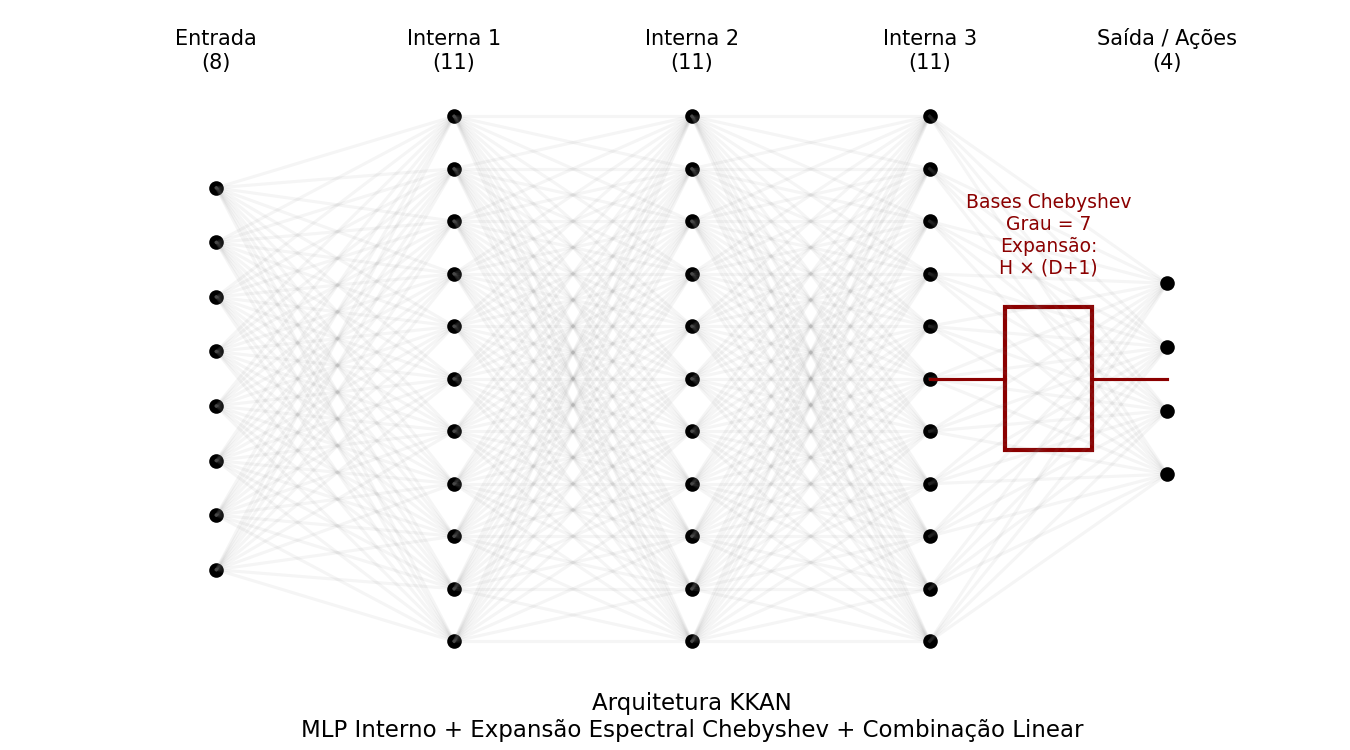

In [ ]:
plot_kkan_arquitetura(input_dim, hidden_layers, cheb_degree, output_dim, save_img)

## Gráficos

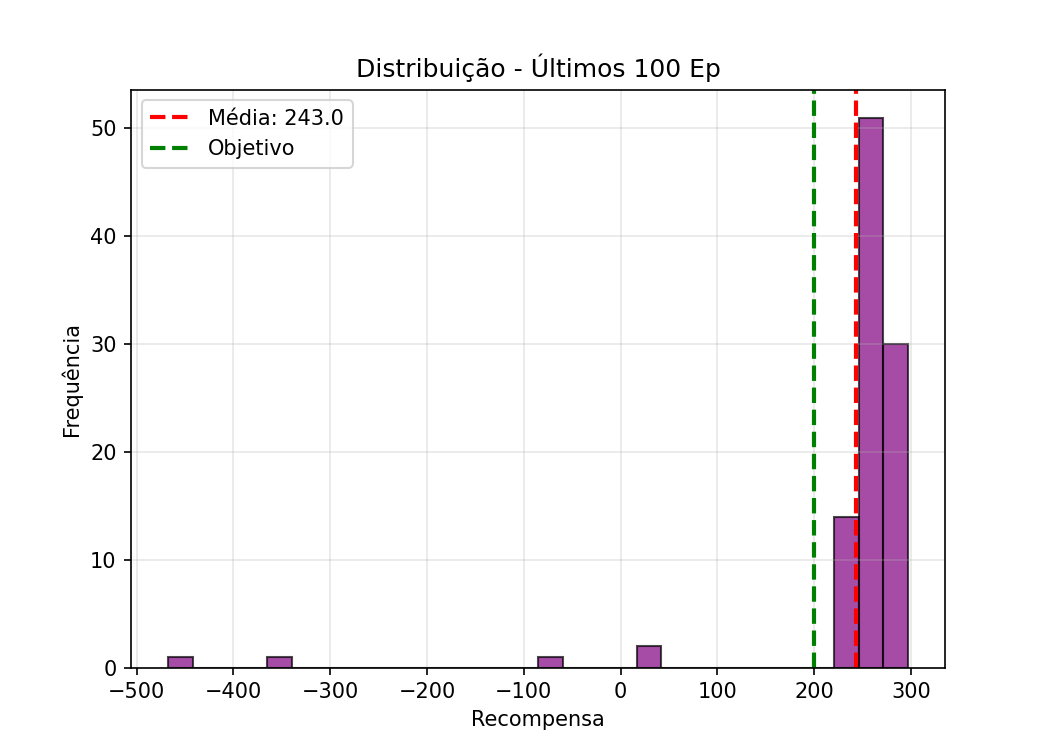

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

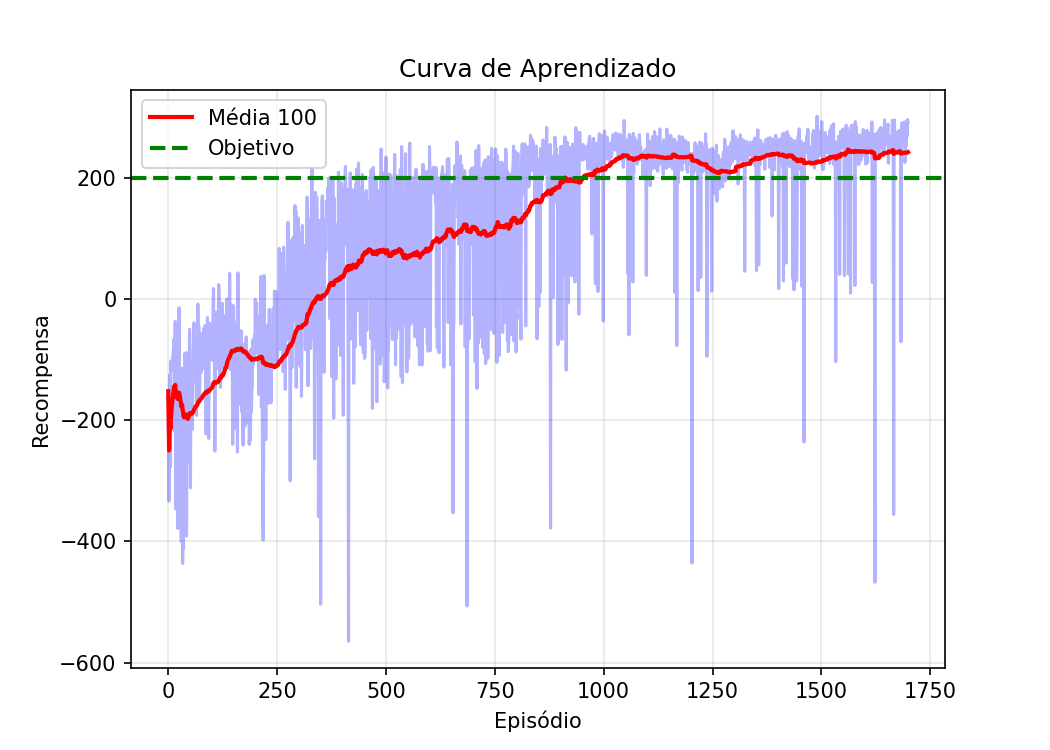

In [ ]:
plot_curva_aprendizado(rewards, save_img)

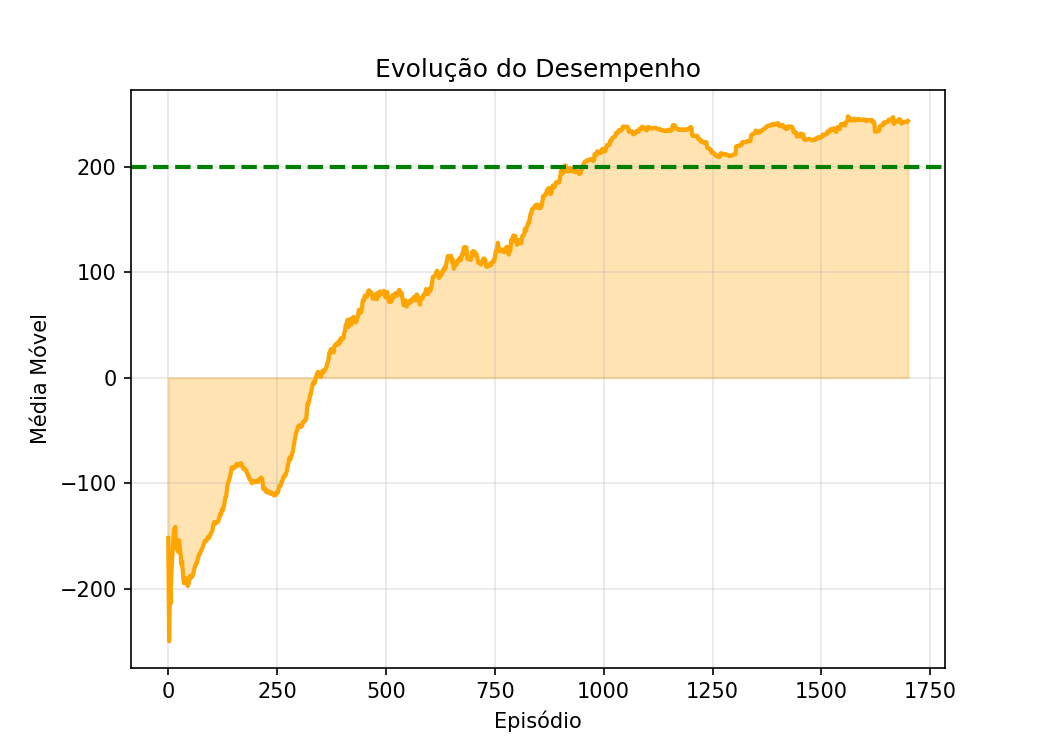

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

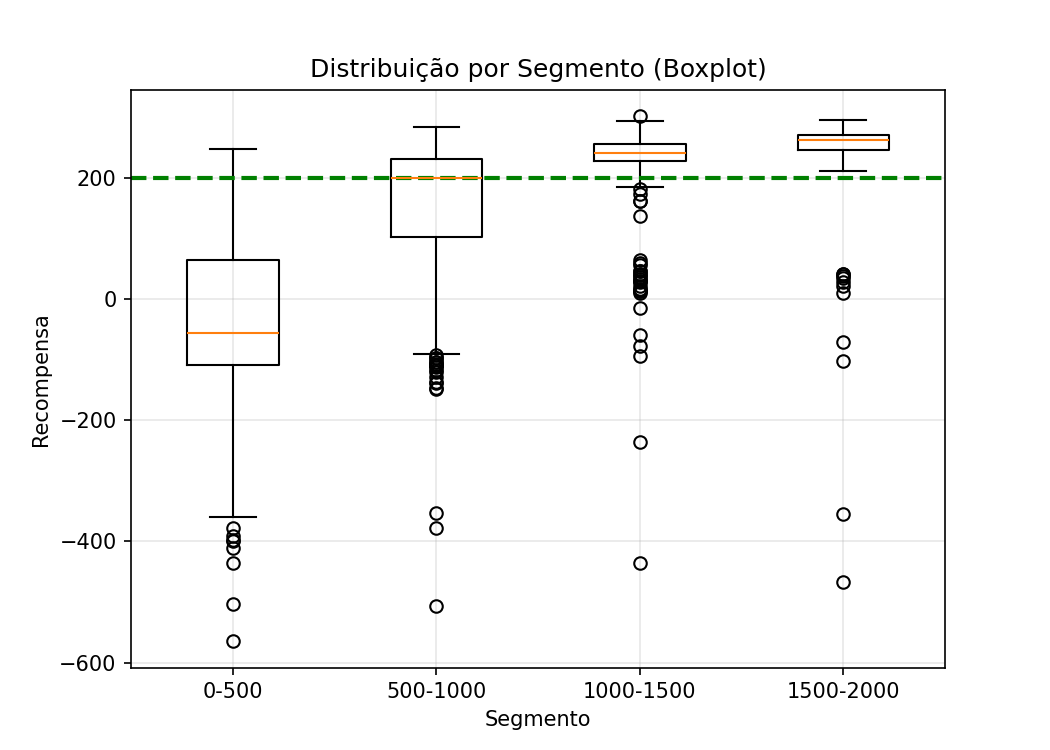

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

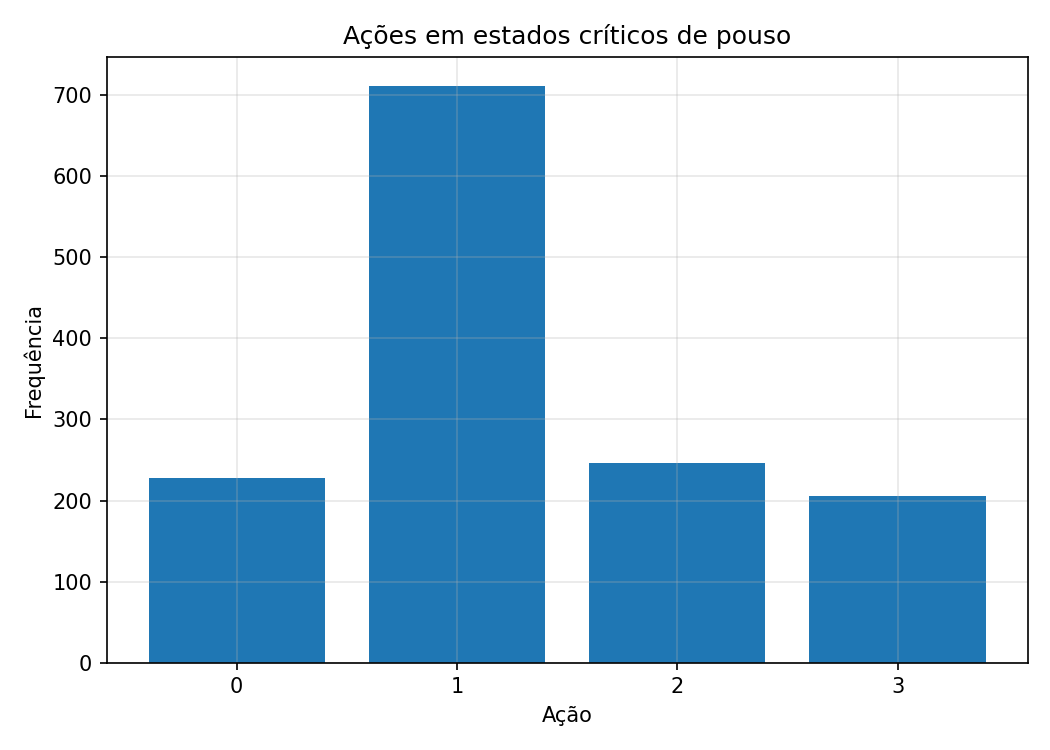

In [ ]:
plot_acoes_em_estado_critico(replay_buffer.buffer, save_img)

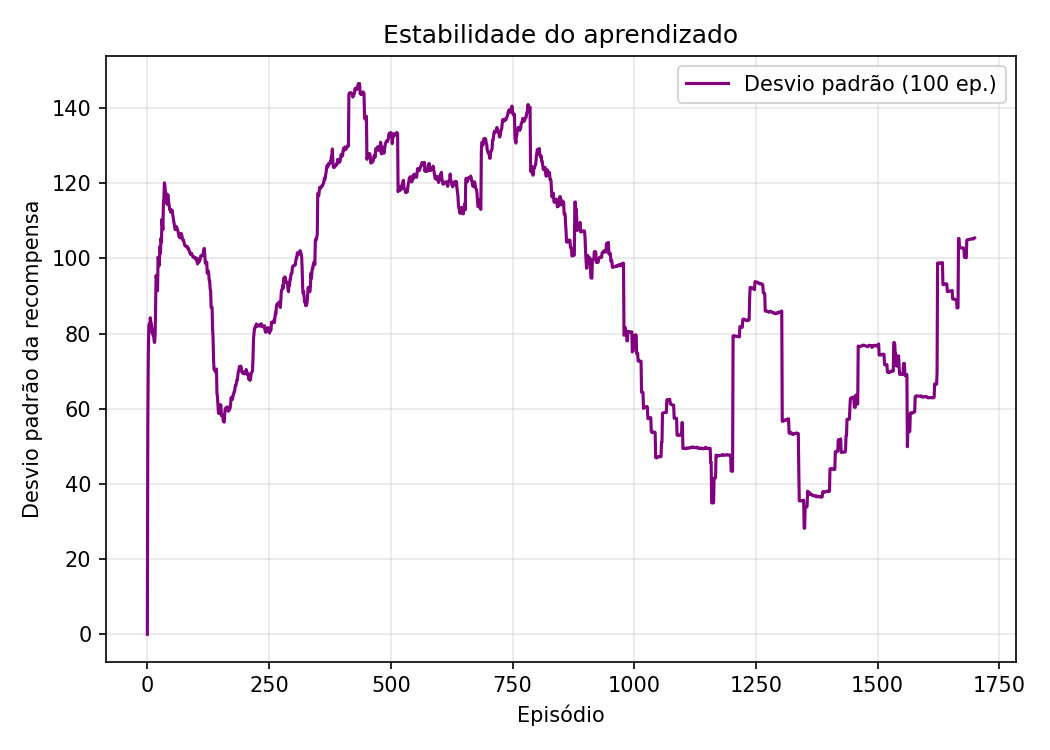

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

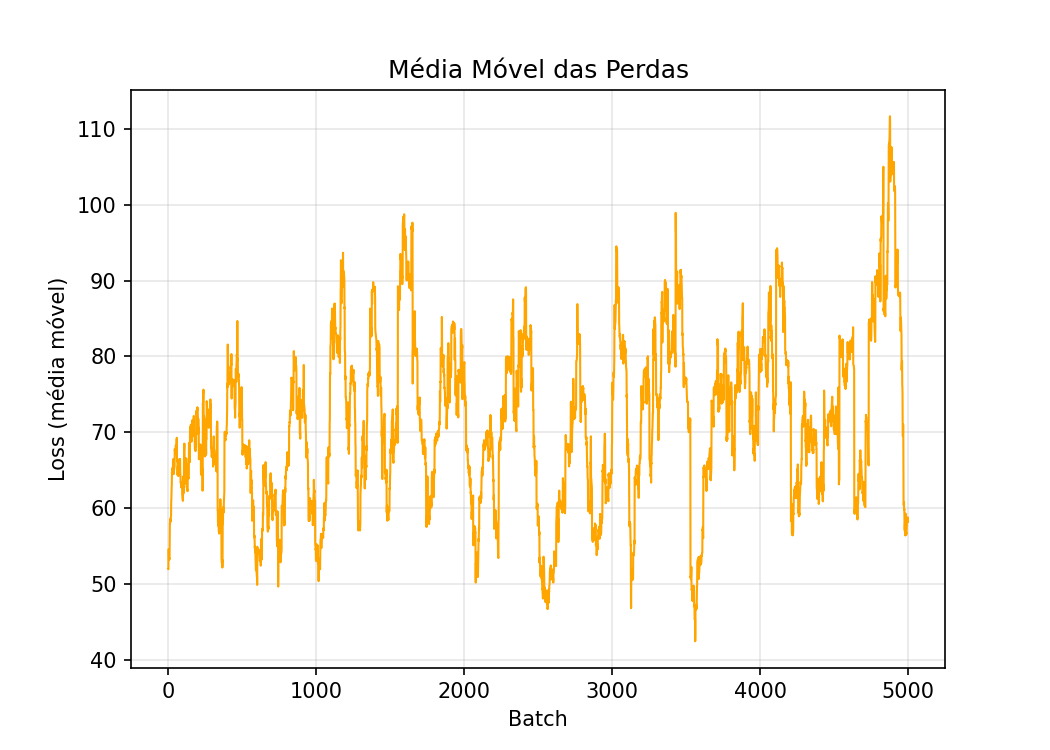

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_be4f7baa83.pt
Vídeo gerado: videos/video-41ef778892-episode-0.mp4
Recompensa total: 258.44


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_be4f7baa83.pt
Vídeo gerado: videos/video-0610138007-episode-0.mp4
Recompensa total: 285.17


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_be4f7baa83.pt
Vídeo gerado: videos/video-27c211b23e-episode-0.mp4
Recompensa total: 286.95


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_be4f7baa83.pt
Vídeo gerado: videos/video-62e5d9ba5a-episode-0.mp4
Recompensa total: 261.04


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_be4f7baa83.pt
Vídeo gerado: videos/video-d40e9a24a4-episode-0.mp4
Recompensa total: 225.85


#5. Execução (160)

In [ ]:
# Parâmetros de Execução Otimizados
seed = 160
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "LunarLander-v3"
num_episodes = 1700
capacity = 800000
batch_size = 16
n_step = 3
tau = 0.001
gamma = 0.99
lr = 5e-4
hidden_layers = [11, 11, 11]
warmup_episodes = 100
cheb_degree = 7 # grau das bases de Chebyshev

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n

# Configuração da rede KKAN
modelo = RLModelKKAN(
    input_dim=input_dim,
    internal_hidden=hidden_layers,
    cheb_degree=cheb_degree,
    output_dim=output_dim
).to(device)

# Inicializa otimizador, agente e buffer
optimizer = torch.optim.Adam(modelo.parameters(), lr, weight_decay=1e-4)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()

nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
)
timer.stop()


(21:17:34) Iniciou execução...
Rodando na cuda:0
Ep    1/1700 [WARMUP] | R: -422.91 | Media10: -422.91 | Media100: -422.91 | eps: 0.995 | Buf:     88
Ep    2/1700 [WARMUP] | R: -225.57 | Media10: -324.24 | Media100: -324.24 | eps: 0.990 | Buf:    164
Ep    3/1700 [WARMUP] | R: -193.88 | Media10: -280.79 | Media100: -280.79 | eps: 0.985 | Buf:    267
Ep    4/1700 [WARMUP] | R: -257.26 | Media10: -274.91 | Media100: -274.91 | eps: 0.980 | Buf:    347
Ep    5/1700 [WARMUP] | R: -214.21 | Media10: -262.77 | Media100: -262.77 | eps: 0.975 | Buf:    422
Ep    6/1700 [WARMUP] | R: -134.25 | Media10: -241.35 | Media100: -241.35 | eps: 0.970 | Buf:    510
Ep    7/1700 [WARMUP] | R:  -86.38 | Media10: -219.21 | Media100: -219.21 | eps: 0.966 | Buf:    578
Ep    8/1700 [WARMUP] | R: -341.03 | Media10: -234.44 | Media100: -234.44 | eps: 0.961 | Buf:    689
Ep    9/1700 [WARMUP] | R: -107.03 | Media10: -220.28 | Media100: -220.28 | eps: 0.956 | Buf:    750
Ep   10/1700 [WARMUP] | R: -116.03 | Media

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'Download {caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

Download resultados/kkan_agente_1044da4fbc.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#6. Resultados (160)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)

## Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 296.27 (episódio 1282)
 Melhor média (100 ep): 259.38 (episódio 1660)
 Média últimos (100 ep): 257.12 ± 16.18
 Taxa de sucesso (>200): 100.0% (100/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelKKAN(
  715, 99.444% Params, 715.0 Mac, 100.000% MACs, 
  (inner): KKANInternalBlock(
    363, 50.487% Params, 363.0 Mac, 50.769% MACs, 
    (rede): Sequential(
      363, 50.487% Params, 363.0 Mac, 50.769% MACs, 
      (0): Linear(99, 13.769% Params, 99.0 Mac, 13.846% MACs, in_features=8, out_features=11, bias=True)
      (1): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
      (2): Linear(132, 18.359% Params, 132.0 Mac, 18.462% MACs, in_features=11, out_features=11, bias=True)
      (3): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
      (4): Linear(132, 18.359% Params, 132.0 Mac, 18.462% MACs, in_features=11, out_features=11, bias=True)
      (5): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    )
  )
  (outer): KKANExternalBlock(
    352, 48.957% Params, 352.0 Mac, 49.231% MACs, 
    (cheb): ChebyshevLayer(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    (linear): Linear(352, 48.957% Params, 352.0 Mac, 49.231% MACs, in_features=88, out_features=4, bias=False)
  )
)
FLOPs (

## Arquitetura da Rede

In [ ]:
print(modelo)

RLModelKKAN(
  (inner): KKANInternalBlock(
    (rede): Sequential(
      (0): Linear(in_features=8, out_features=11, bias=True)
      (1): Tanh()
      (2): Linear(in_features=11, out_features=11, bias=True)
      (3): Tanh()
      (4): Linear(in_features=11, out_features=11, bias=True)
      (5): Tanh()
    )
  )
  (outer): KKANExternalBlock(
    (cheb): ChebyshevLayer()
    (linear): Linear(in_features=88, out_features=4, bias=False)
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
RLModelKKAN                              [1, 4]                    --
├─KKANInternalBlock: 1-1                 [1, 11]                   --
│    └─Sequential: 2-1                   [1, 11]                   --
│    │    └─Linear: 3-1                  [1, 11]                   99
│    │    └─Tanh: 3-2                    [1, 11]                   --
│    │    └─Linear: 3-3                  [1, 11]                   132
│    │    └─Tanh: 3-4                    [1, 11]                   --
│    │    └─Linear: 3-5                  [1, 11]                   132
│    │    └─Tanh: 3-6                    [1, 11]                   --
├─KKANExternalBlock: 1-2                 [1, 4]                    4
│    └─ChebyshevLayer: 2-2               [1, 88]                   --
│    └─Linear: 2-3                       [1, 4]                    352
Total params: 719
Trainable params: 719
Non-trainable params: 0
Total mult-adds (Un

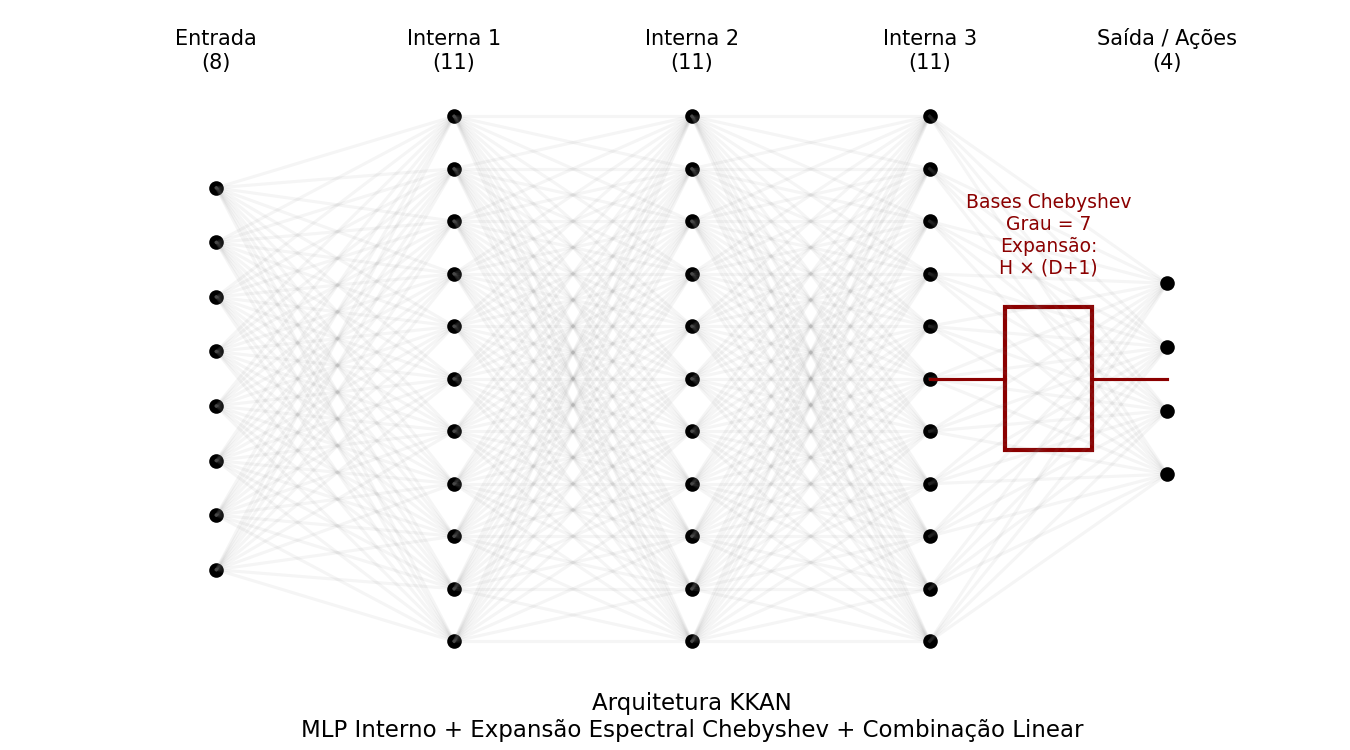

In [ ]:
plot_kkan_arquitetura(input_dim, hidden_layers, cheb_degree, output_dim, save_img)

## Gráficos

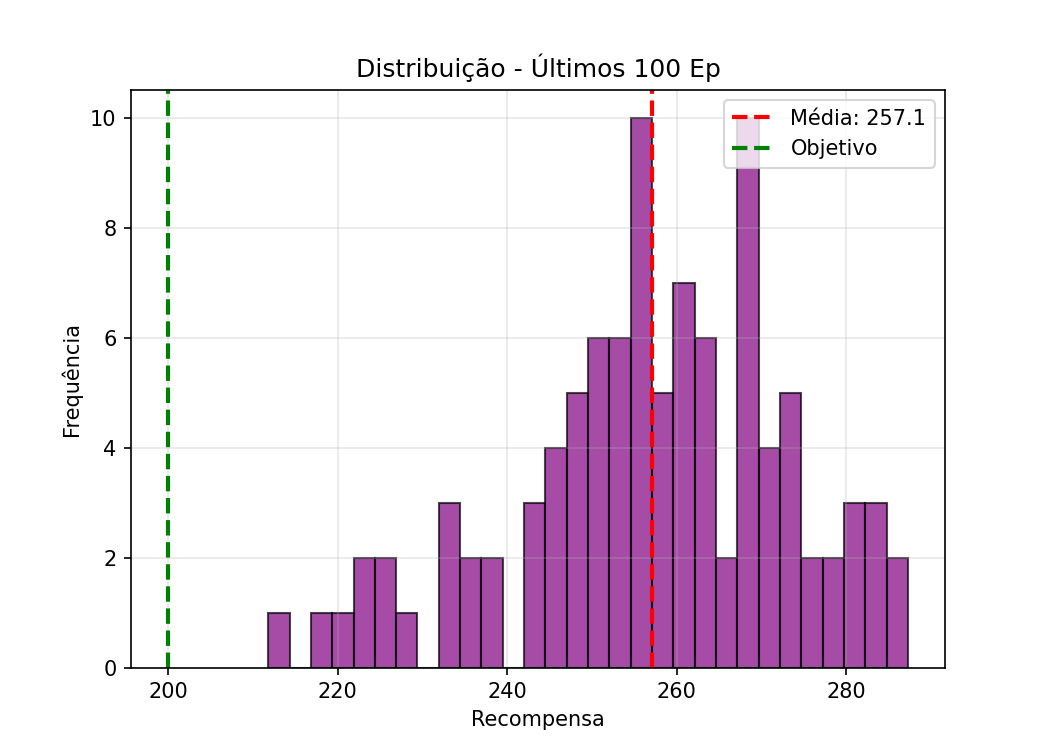

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

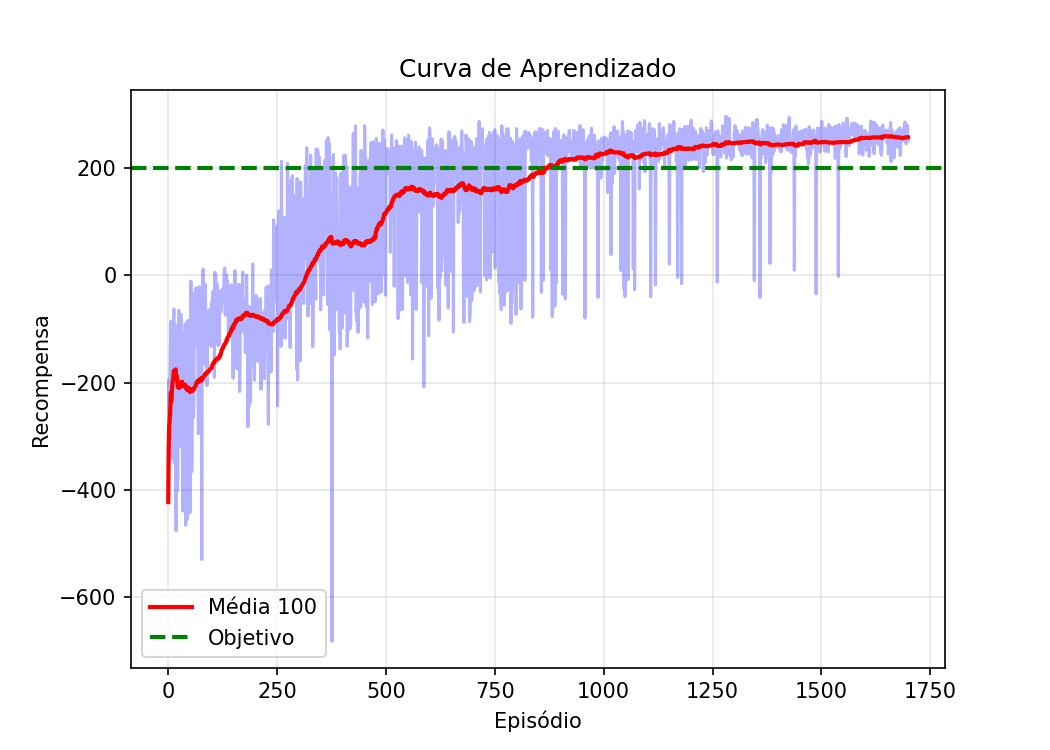

In [ ]:
plot_curva_aprendizado(rewards, save_img)

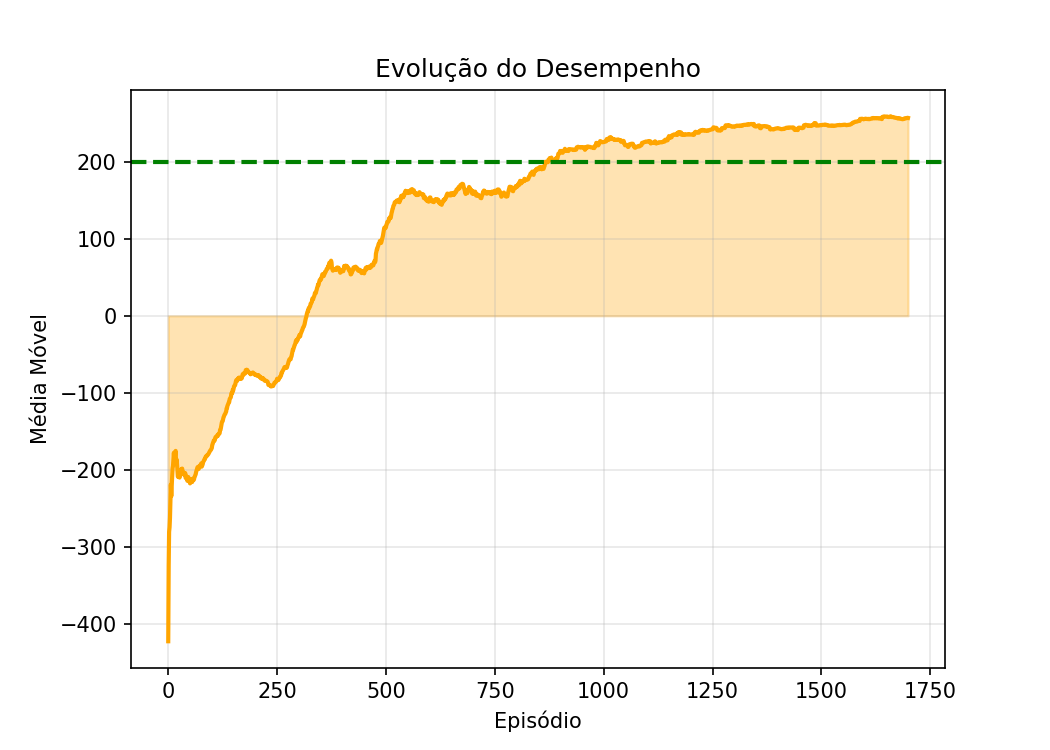

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

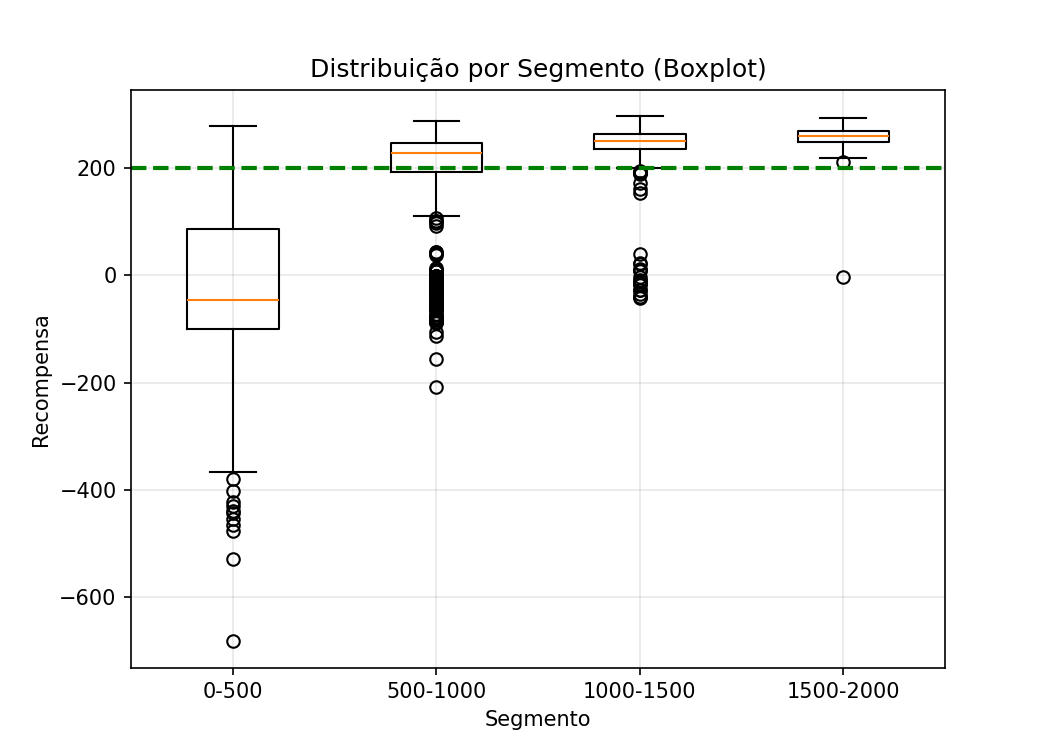

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

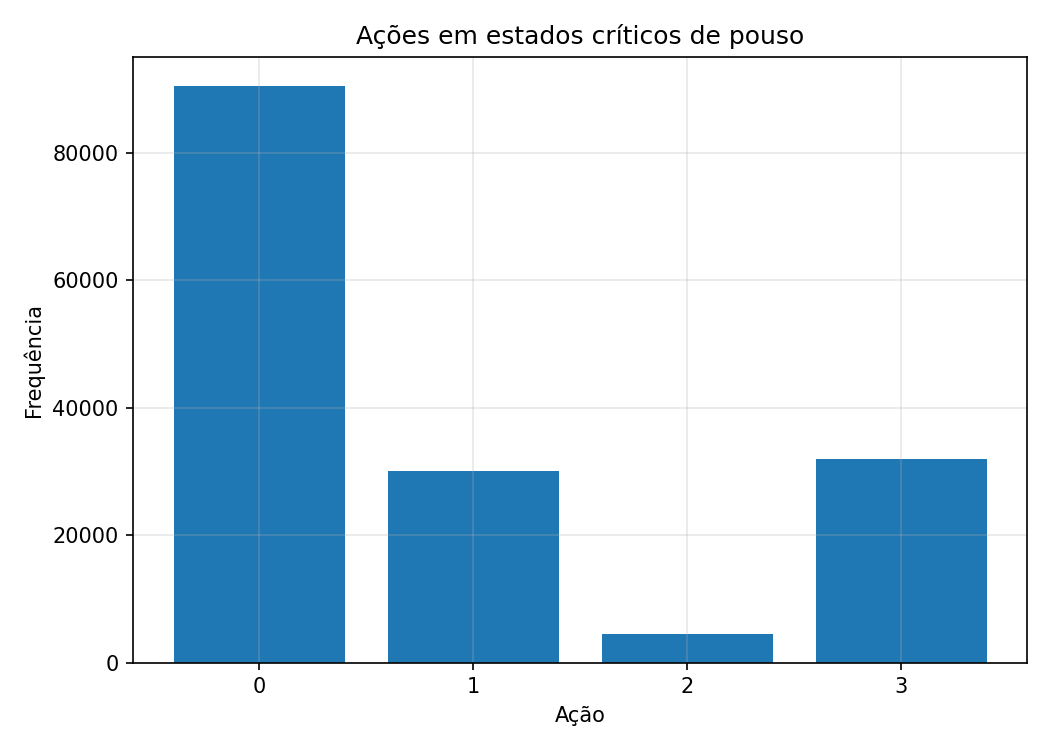

In [ ]:
plot_acoes_em_estado_critico(replay_buffer.buffer, save_img)

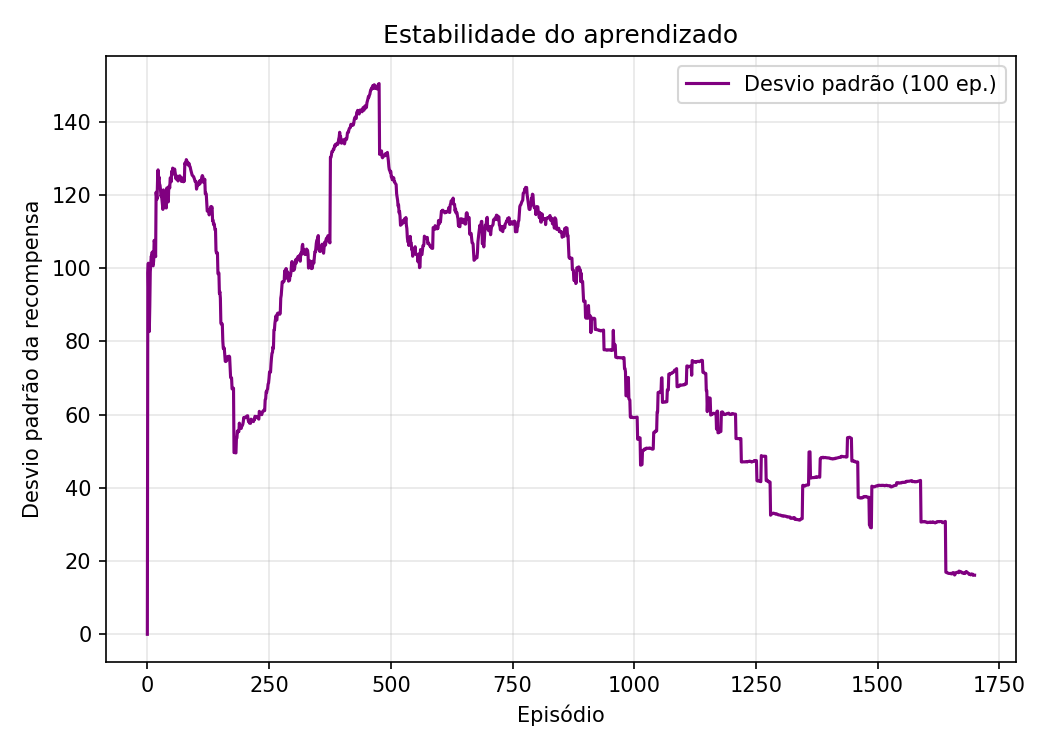

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

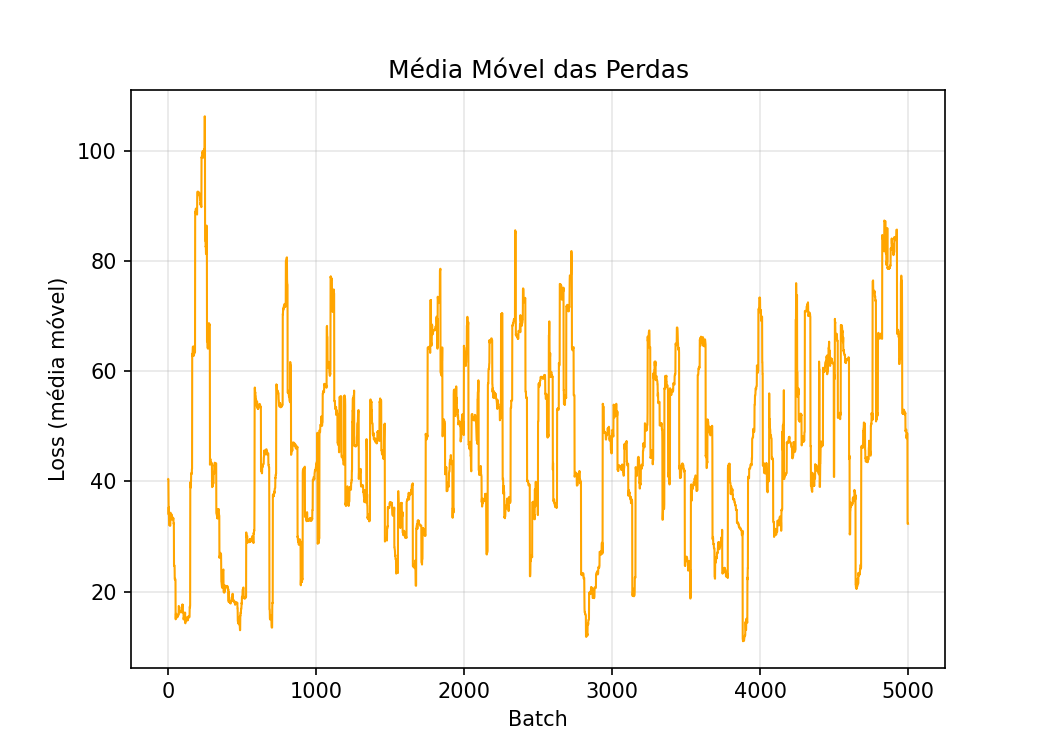

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_1044da4fbc.pt
Vídeo gerado: videos/video-d048c0c28b-episode-0.mp4
Recompensa total: 242.81


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_1044da4fbc.pt
Vídeo gerado: videos/video-5dd0b118c0-episode-0.mp4
Recompensa total: 187.03


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_1044da4fbc.pt
Vídeo gerado: videos/video-9afea81930-episode-0.mp4
Recompensa total: 228.91


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_1044da4fbc.pt
Vídeo gerado: videos/video-6eaad64f9c-episode-0.mp4
Recompensa total: 218.80


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_1044da4fbc.pt
Vídeo gerado: videos/video-523b63f43a-episode-0.mp4
Recompensa total: 115.53


#5. Execução (198)


In [10]:
# Parâmetros de Execução Otimizados
seed = 198
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "LunarLander-v3"
num_episodes = 1700
capacity = 800000
batch_size = 16
n_step = 3
tau = 0.001
gamma = 0.99
lr = 5e-4
hidden_layers = [11, 11, 11]
warmup_episodes = 100
cheb_degree = 7 # grau das bases de Chebyshev

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n

# Configuração da rede KKAN
modelo = RLModelKKAN(
    input_dim=input_dim,
    internal_hidden=hidden_layers,
    cheb_degree=cheb_degree,
    output_dim=output_dim
).to(device)

# Inicializa otimizador, agente e buffer
optimizer = torch.optim.Adam(modelo.parameters(), lr, weight_decay=1e-4)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()

nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
)
timer.stop()


(16:22:29) Iniciou execução...
Rodando na cuda:0
Ep    1/1700 [WARMUP] | R: -131.12 | Media10: -131.12 | Media100: -131.12 | eps: 0.995 | Buf:     58
Ep    2/1700 [WARMUP] | R:  -98.39 | Media10: -114.76 | Media100: -114.76 | eps: 0.990 | Buf:    150
Ep    3/1700 [WARMUP] | R: -118.92 | Media10: -116.15 | Media100: -116.15 | eps: 0.985 | Buf:    232
Ep    4/1700 [WARMUP] | R: -173.90 | Media10: -130.58 | Media100: -130.58 | eps: 0.980 | Buf:    313
Ep    5/1700 [WARMUP] | R:  -82.29 | Media10: -120.92 | Media100: -120.92 | eps: 0.975 | Buf:    395
Ep    6/1700 [WARMUP] | R:  -74.28 | Media10: -113.15 | Media100: -113.15 | eps: 0.970 | Buf:    472
Ep    7/1700 [WARMUP] | R: -110.53 | Media10: -112.78 | Media100: -112.78 | eps: 0.966 | Buf:    548
Ep    8/1700 [WARMUP] | R: -353.38 | Media10: -142.85 | Media100: -142.85 | eps: 0.961 | Buf:    662
Ep    9/1700 [WARMUP] | R:  -96.53 | Media10: -137.70 | Media100: -137.70 | eps: 0.956 | Buf:    777
Ep   10/1700 [WARMUP] | R:  -77.52 | Media

In [11]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'Download {caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

Download resultados/kkan_agente_3cf6b16e26.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#6. Resultados (198)

In [12]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)

seed 198
device cuda
env_name LunarLander-v3
num_episodes 1700
capacity 800000
batch_size 16
n_step 3
tau 0.001
gamma 0.99
lr 0.0005
hidden_layers [11, 11, 11]
warmup_episodes 100


## Desempenho

In [13]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 294.31 (episódio 1457)
 Melhor média (100 ep): 221.09 (episódio 1636)
 Média últimos (100 ep): 207.01 ± 142.83
 Taxa de sucesso (>200): 88.0% (88/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [14]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelKKAN(
  715, 99.444% Params, 715.0 Mac, 100.000% MACs, 
  (inner): KKANInternalBlock(
    363, 50.487% Params, 363.0 Mac, 50.769% MACs, 
    (rede): Sequential(
      363, 50.487% Params, 363.0 Mac, 50.769% MACs, 
      (0): Linear(99, 13.769% Params, 99.0 Mac, 13.846% MACs, in_features=8, out_features=11, bias=True)
      (1): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
      (2): Linear(132, 18.359% Params, 132.0 Mac, 18.462% MACs, in_features=11, out_features=11, bias=True)
      (3): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
      (4): Linear(132, 18.359% Params, 132.0 Mac, 18.462% MACs, in_features=11, out_features=11, bias=True)
      (5): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    )
  )
  (outer): KKANExternalBlock(
    352, 48.957% Params, 352.0 Mac, 49.231% MACs, 
    (cheb): ChebyshevLayer(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    (linear): Linear(352, 48.957% Params, 352.0 Mac, 49.231% MACs, in_features=88, out_features=4, bias=False)
  )
)
FLOPs (

## Arquitetura da Rede

In [15]:
print(modelo)

RLModelKKAN(
  (inner): KKANInternalBlock(
    (rede): Sequential(
      (0): Linear(in_features=8, out_features=11, bias=True)
      (1): Tanh()
      (2): Linear(in_features=11, out_features=11, bias=True)
      (3): Tanh()
      (4): Linear(in_features=11, out_features=11, bias=True)
      (5): Tanh()
    )
  )
  (outer): KKANExternalBlock(
    (cheb): ChebyshevLayer()
    (linear): Linear(in_features=88, out_features=4, bias=False)
  )
)


In [16]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
RLModelKKAN                              [1, 4]                    --
├─KKANInternalBlock: 1-1                 [1, 11]                   --
│    └─Sequential: 2-1                   [1, 11]                   --
│    │    └─Linear: 3-1                  [1, 11]                   99
│    │    └─Tanh: 3-2                    [1, 11]                   --
│    │    └─Linear: 3-3                  [1, 11]                   132
│    │    └─Tanh: 3-4                    [1, 11]                   --
│    │    └─Linear: 3-5                  [1, 11]                   132
│    │    └─Tanh: 3-6                    [1, 11]                   --
├─KKANExternalBlock: 1-2                 [1, 4]                    4
│    └─ChebyshevLayer: 2-2               [1, 88]                   --
│    └─Linear: 2-3                       [1, 4]                    352
Total params: 719
Trainable params: 719
Non-trainable params: 0
Total mult-adds (Un

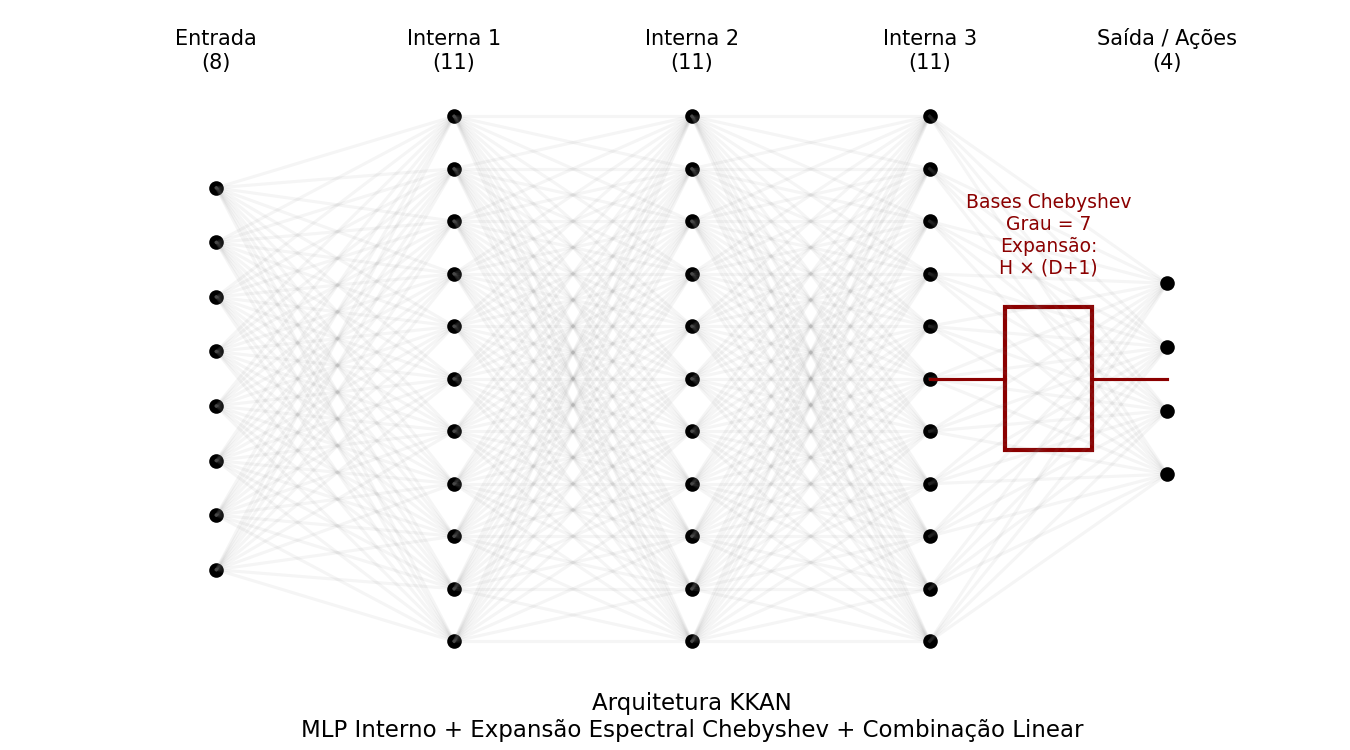

In [17]:
plot_kkan_arquitetura(input_dim, hidden_layers, cheb_degree, output_dim, save_img)

## Gráficos

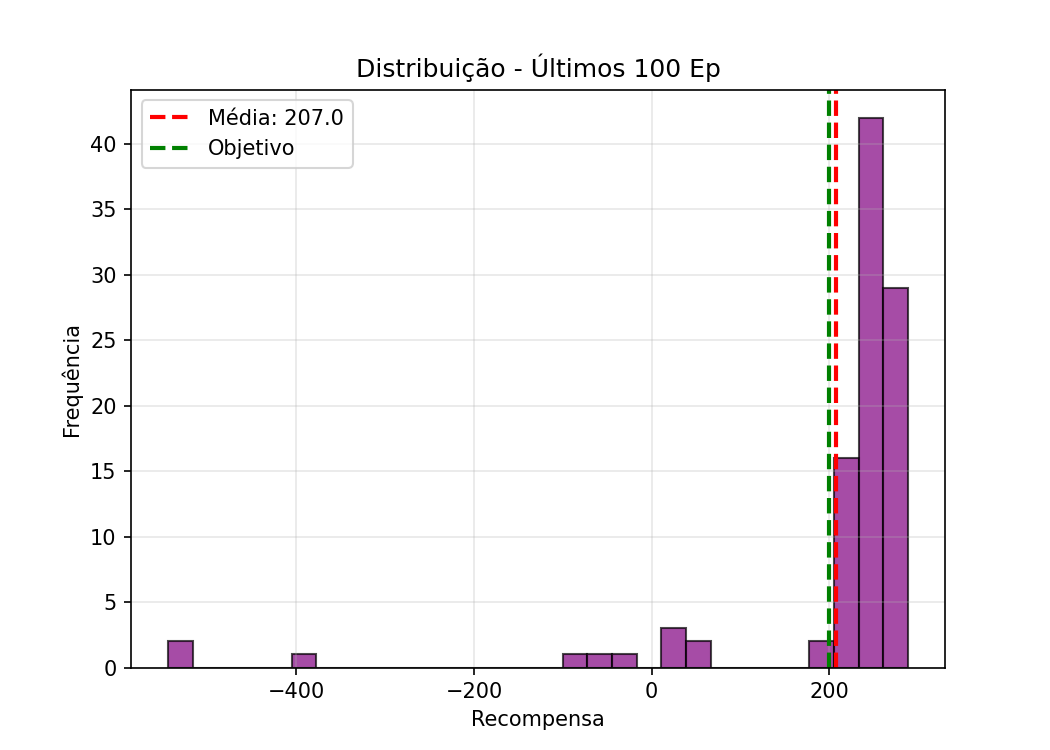

In [18]:
plot_distribuicao_recompensa(rewards, save_img)

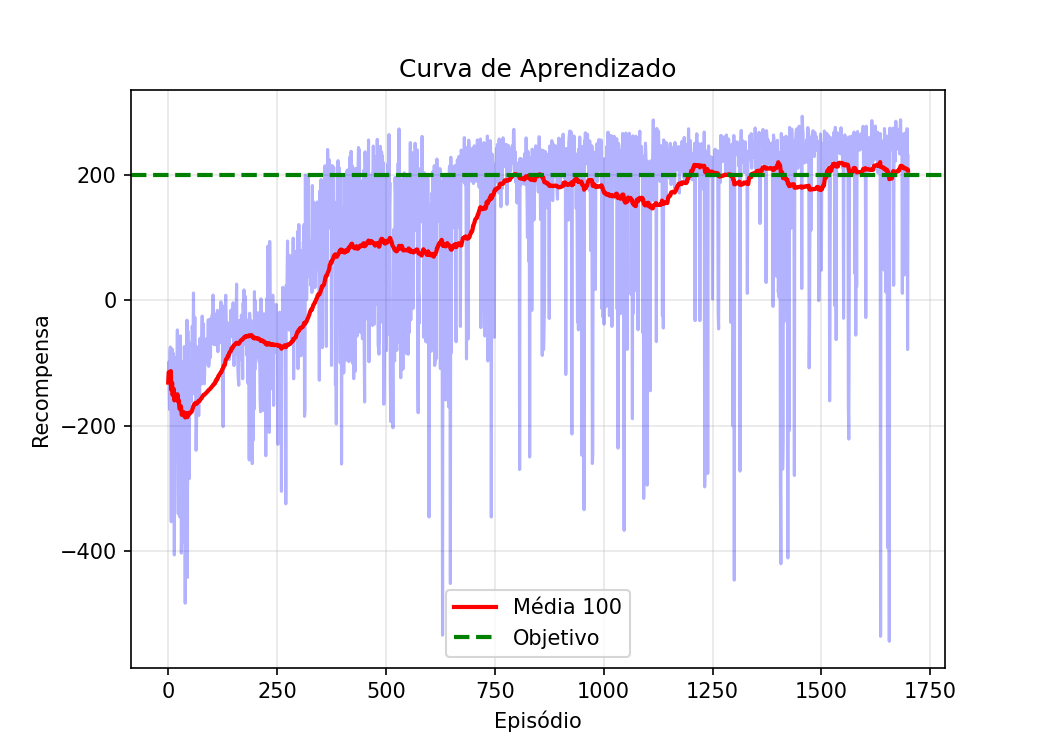

In [19]:
plot_curva_aprendizado(rewards, save_img)

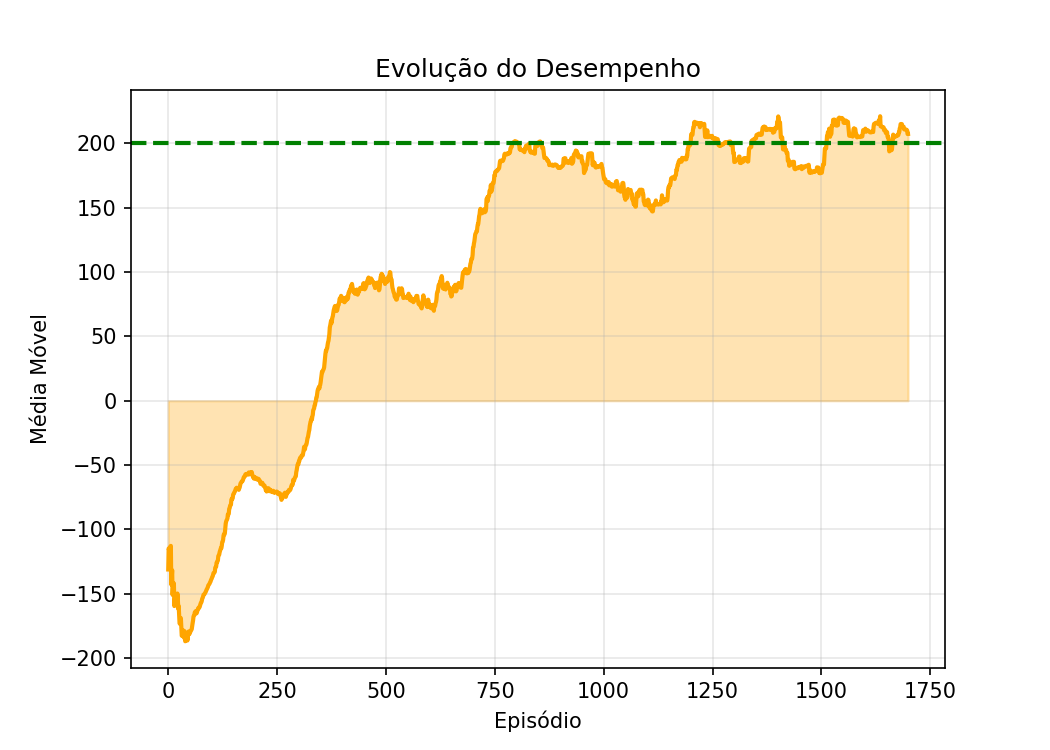

In [20]:
plot_evolucao_desempenho(rewards, save_img)

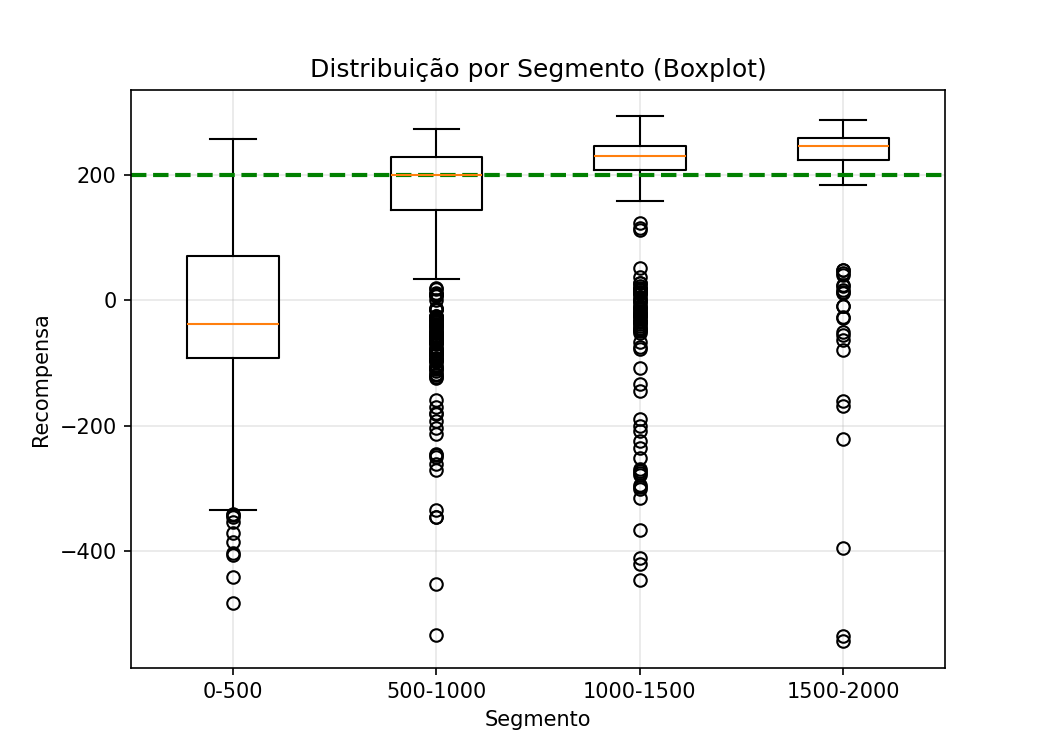

In [21]:
plot_distribuicao_segmento(rewards, save_img)

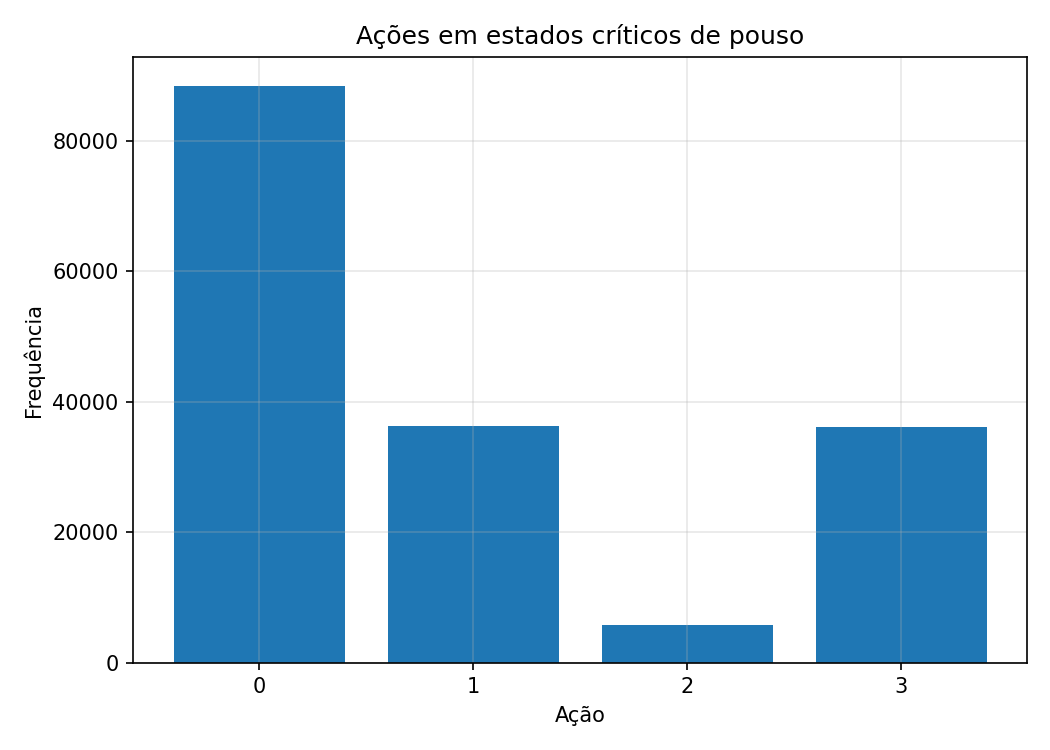

In [22]:
plot_acoes_em_estado_critico(replay_buffer.buffer, save_img)

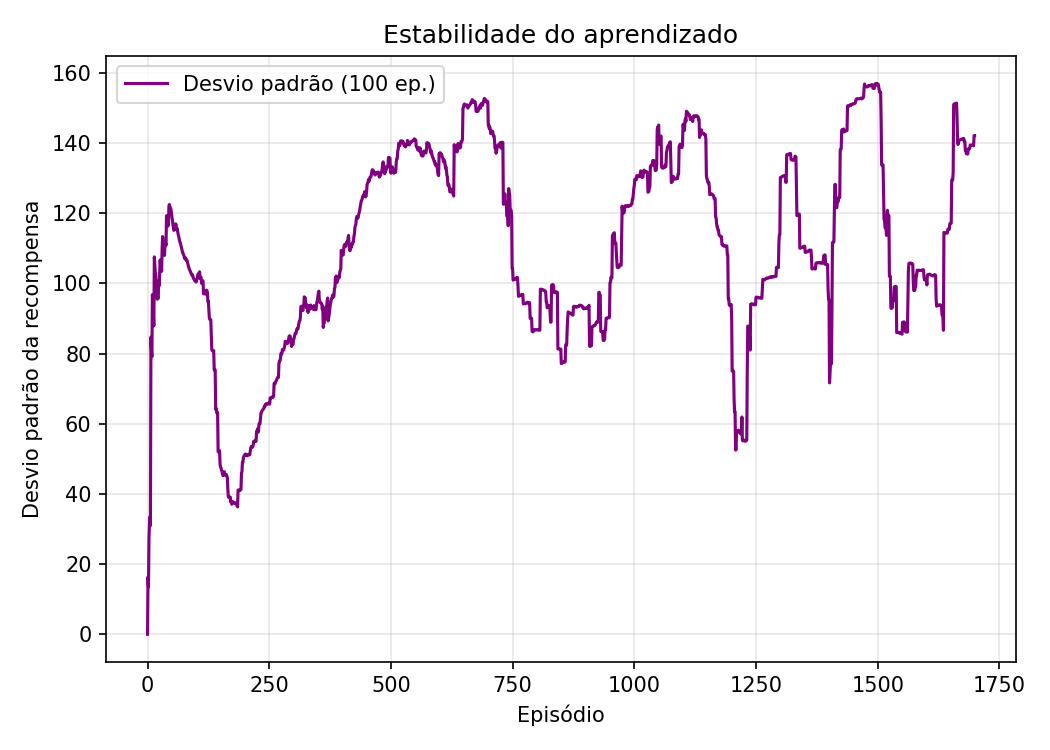

In [23]:
plot_desvio_padrao_recompensa(rewards, save_img)

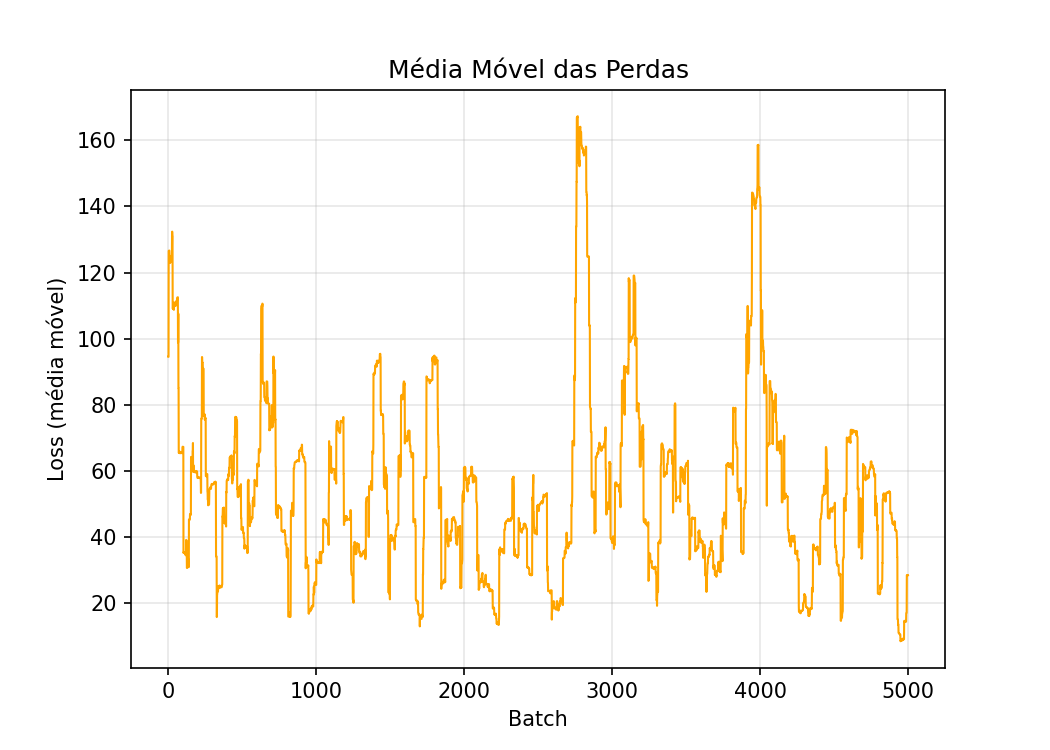

In [24]:
plot_losses(agent.losses, save_img)

##Vídeos

In [25]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_3cf6b16e26.pt
Vídeo gerado: videos/video-be9a5dcb26-episode-0.mp4
Recompensa total: 278.80


In [26]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_3cf6b16e26.pt
Vídeo gerado: videos/video-ca1afe95c8-episode-0.mp4
Recompensa total: 201.15


In [27]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_3cf6b16e26.pt
Vídeo gerado: videos/video-23af650d08-episode-0.mp4
Recompensa total: 238.93


In [28]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_3cf6b16e26.pt
Vídeo gerado: videos/video-c656b6caee-episode-0.mp4
Recompensa total: 191.83


In [29]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_3cf6b16e26.pt
Vídeo gerado: videos/video-a1db969ae0-episode-0.mp4
Recompensa total: 50.86


#5. Execução (254)

In [ ]:
# Parâmetros de Execução Otimizados
seed = 254
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "LunarLander-v3"
num_episodes = 1700
capacity = 800000
batch_size = 16
n_step = 3
tau = 0.001
gamma = 0.99
lr = 5e-4
hidden_layers = [11, 11, 11]
warmup_episodes = 100
cheb_degree = 7 # grau das bases de Chebyshev

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n

# Configuração da rede KKAN
modelo = RLModelKKAN(
    input_dim=input_dim,
    internal_hidden=hidden_layers,
    cheb_degree=cheb_degree,
    output_dim=output_dim
).to(device)

# Inicializa otimizador, agente e buffer
optimizer = torch.optim.Adam(modelo.parameters(), lr, weight_decay=1e-4)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()

nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
)
timer.stop()


(03:17:15) Iniciou execução...
Rodando na cuda:0
Ep    1/1700 [WARMUP] | R:  -85.21 | Media10:  -85.21 | Media100:  -85.21 | eps: 0.995 | Buf:     63
Ep    2/1700 [WARMUP] | R:  -67.35 | Media10:  -76.28 | Media100:  -76.28 | eps: 0.990 | Buf:    169
Ep    3/1700 [WARMUP] | R: -102.86 | Media10:  -85.14 | Media100:  -85.14 | eps: 0.985 | Buf:    245
Ep    4/1700 [WARMUP] | R: -109.45 | Media10:  -91.22 | Media100:  -91.22 | eps: 0.980 | Buf:    326
Ep    5/1700 [WARMUP] | R: -430.79 | Media10: -159.13 | Media100: -159.13 | eps: 0.975 | Buf:    459
Ep    6/1700 [WARMUP] | R:  -69.58 | Media10: -144.21 | Media100: -144.21 | eps: 0.970 | Buf:    532
Ep    7/1700 [WARMUP] | R: -475.11 | Media10: -191.48 | Media100: -191.48 | eps: 0.966 | Buf:    647
Ep    8/1700 [WARMUP] | R: -110.15 | Media10: -181.31 | Media100: -181.31 | eps: 0.961 | Buf:    741
Ep    9/1700 [WARMUP] | R: -131.22 | Media10: -175.75 | Media100: -175.75 | eps: 0.956 | Buf:    846
Ep   10/1700 [WARMUP] | R: -254.19 | Media

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'Download {caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

Download resultados/kkan_agente_f3308dab32.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#6. Resultados (254)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)

## Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 284.71 (episódio 486)
 Melhor média (100 ep): 234.98 (episódio 1672)
 Média últimos (100 ep): 225.75 ± 69.81
 Taxa de sucesso (>200): 92.0% (92/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelKKAN(
  715, 99.444% Params, 715.0 Mac, 100.000% MACs, 
  (inner): KKANInternalBlock(
    363, 50.487% Params, 363.0 Mac, 50.769% MACs, 
    (rede): Sequential(
      363, 50.487% Params, 363.0 Mac, 50.769% MACs, 
      (0): Linear(99, 13.769% Params, 99.0 Mac, 13.846% MACs, in_features=8, out_features=11, bias=True)
      (1): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
      (2): Linear(132, 18.359% Params, 132.0 Mac, 18.462% MACs, in_features=11, out_features=11, bias=True)
      (3): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
      (4): Linear(132, 18.359% Params, 132.0 Mac, 18.462% MACs, in_features=11, out_features=11, bias=True)
      (5): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    )
  )
  (outer): KKANExternalBlock(
    352, 48.957% Params, 352.0 Mac, 49.231% MACs, 
    (cheb): ChebyshevLayer(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    (linear): Linear(352, 48.957% Params, 352.0 Mac, 49.231% MACs, in_features=88, out_features=4, bias=False)
  )
)
FLOPs (

## Arquitetura da Rede

In [ ]:
print(modelo)

RLModelKKAN(
  (inner): KKANInternalBlock(
    (rede): Sequential(
      (0): Linear(in_features=8, out_features=11, bias=True)
      (1): Tanh()
      (2): Linear(in_features=11, out_features=11, bias=True)
      (3): Tanh()
      (4): Linear(in_features=11, out_features=11, bias=True)
      (5): Tanh()
    )
  )
  (outer): KKANExternalBlock(
    (cheb): ChebyshevLayer()
    (linear): Linear(in_features=88, out_features=4, bias=False)
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
RLModelKKAN                              [1, 4]                    --
├─KKANInternalBlock: 1-1                 [1, 11]                   --
│    └─Sequential: 2-1                   [1, 11]                   --
│    │    └─Linear: 3-1                  [1, 11]                   99
│    │    └─Tanh: 3-2                    [1, 11]                   --
│    │    └─Linear: 3-3                  [1, 11]                   132
│    │    └─Tanh: 3-4                    [1, 11]                   --
│    │    └─Linear: 3-5                  [1, 11]                   132
│    │    └─Tanh: 3-6                    [1, 11]                   --
├─KKANExternalBlock: 1-2                 [1, 4]                    4
│    └─ChebyshevLayer: 2-2               [1, 88]                   --
│    └─Linear: 2-3                       [1, 4]                    352
Total params: 719
Trainable params: 719
Non-trainable params: 0
Total mult-adds (Un

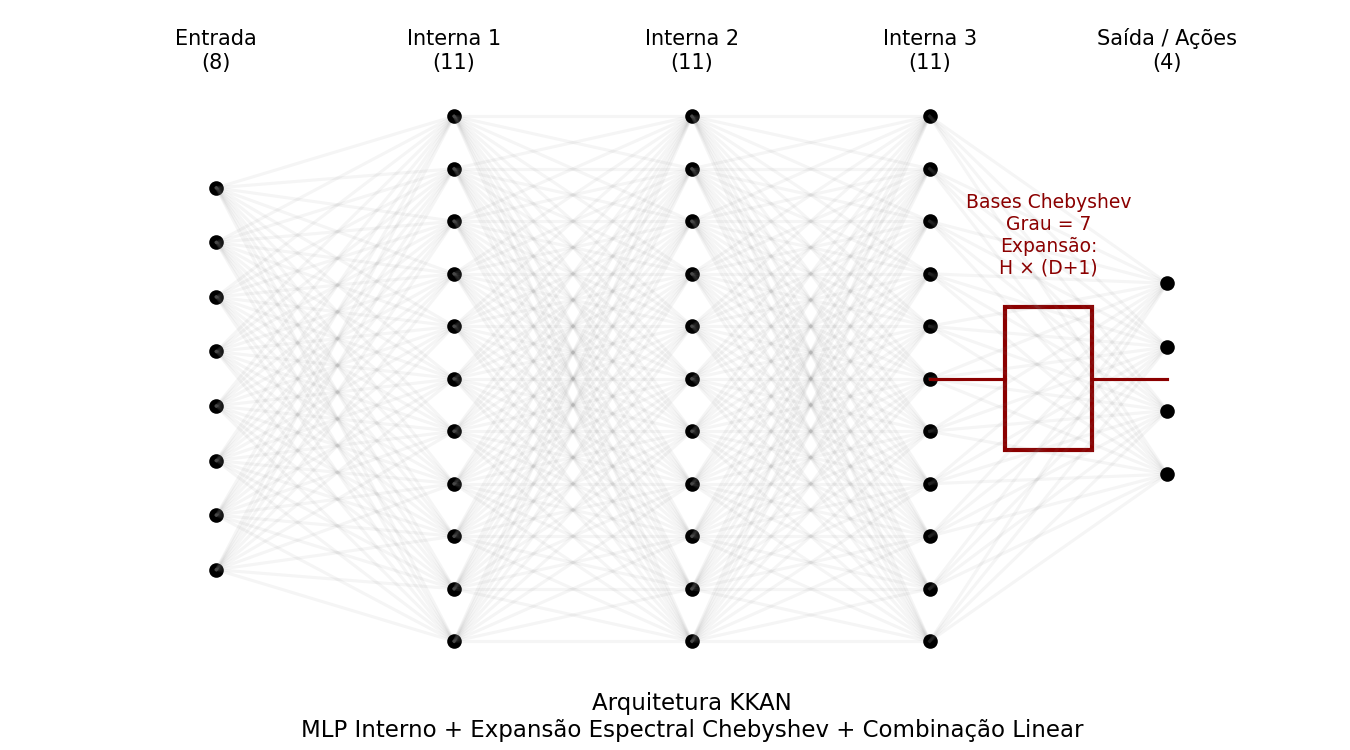

In [ ]:
plot_kkan_arquitetura(input_dim, hidden_layers, cheb_degree, output_dim, save_img)

## Gráficos

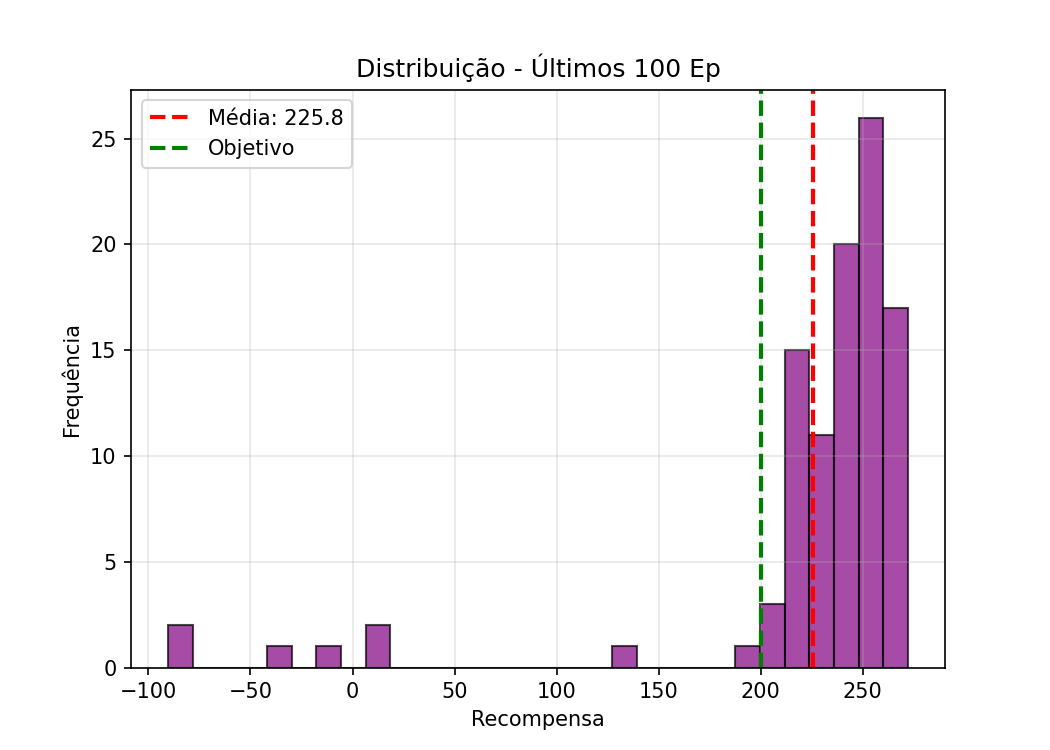

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

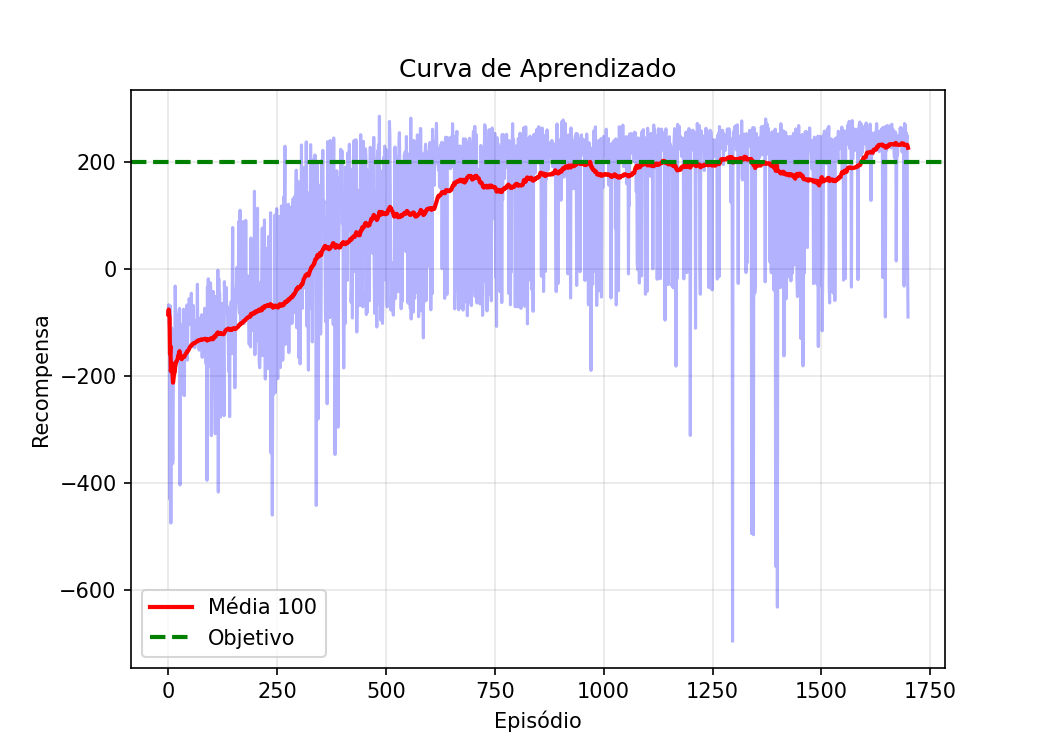

In [ ]:
plot_curva_aprendizado(rewards, save_img)

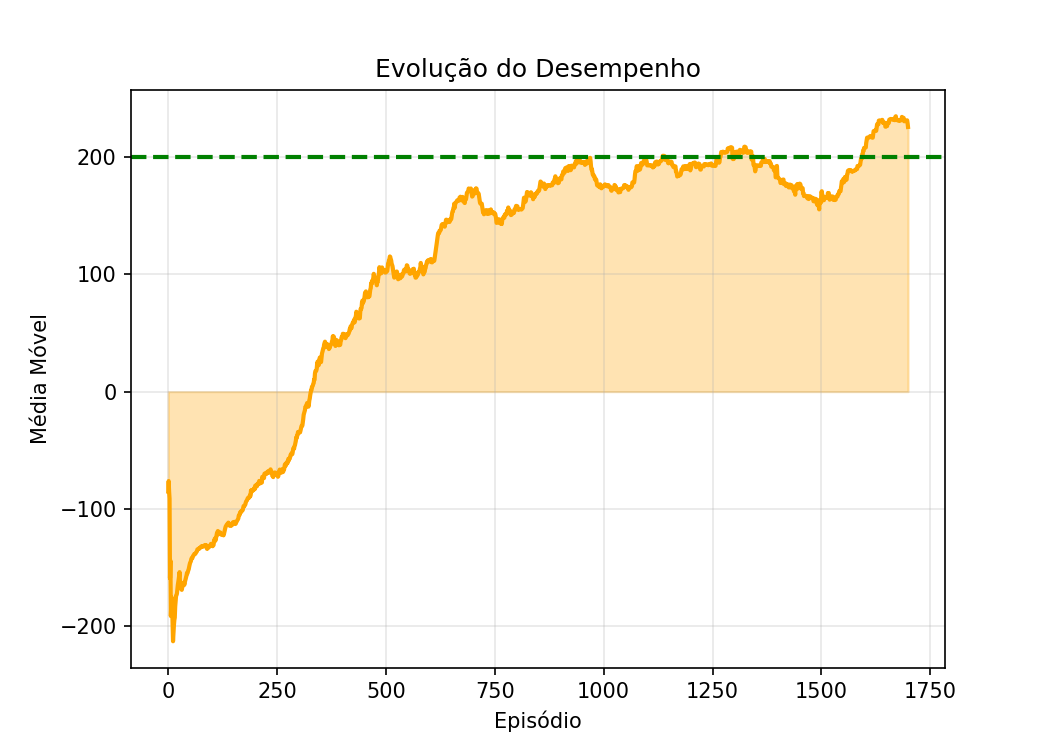

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

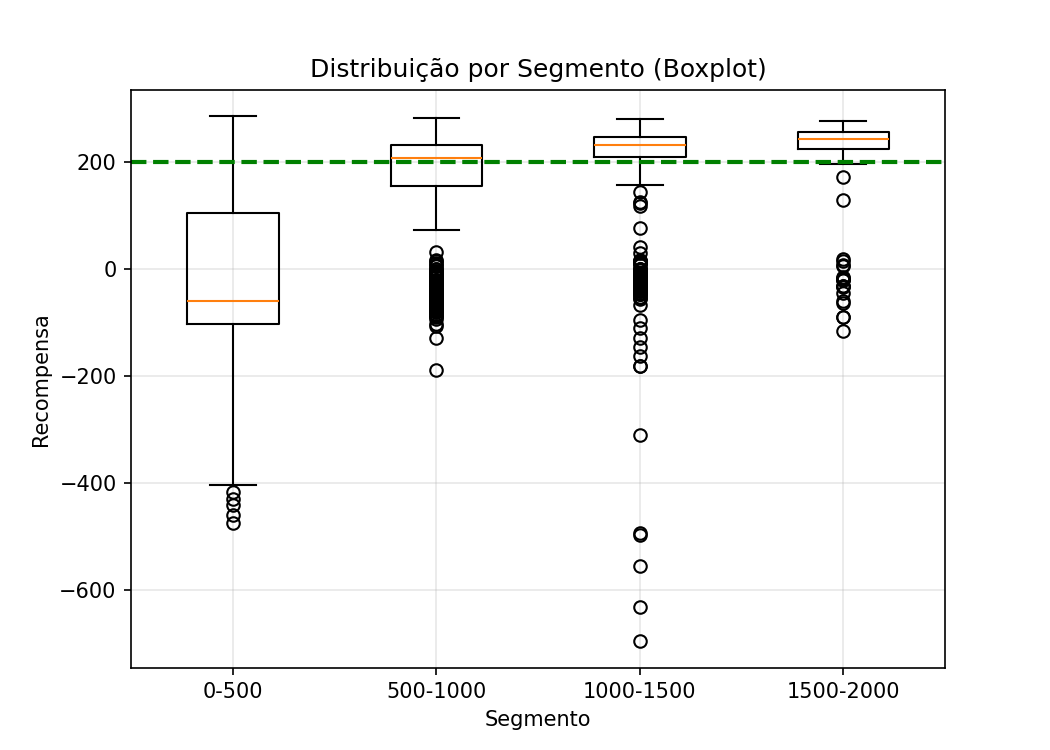

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

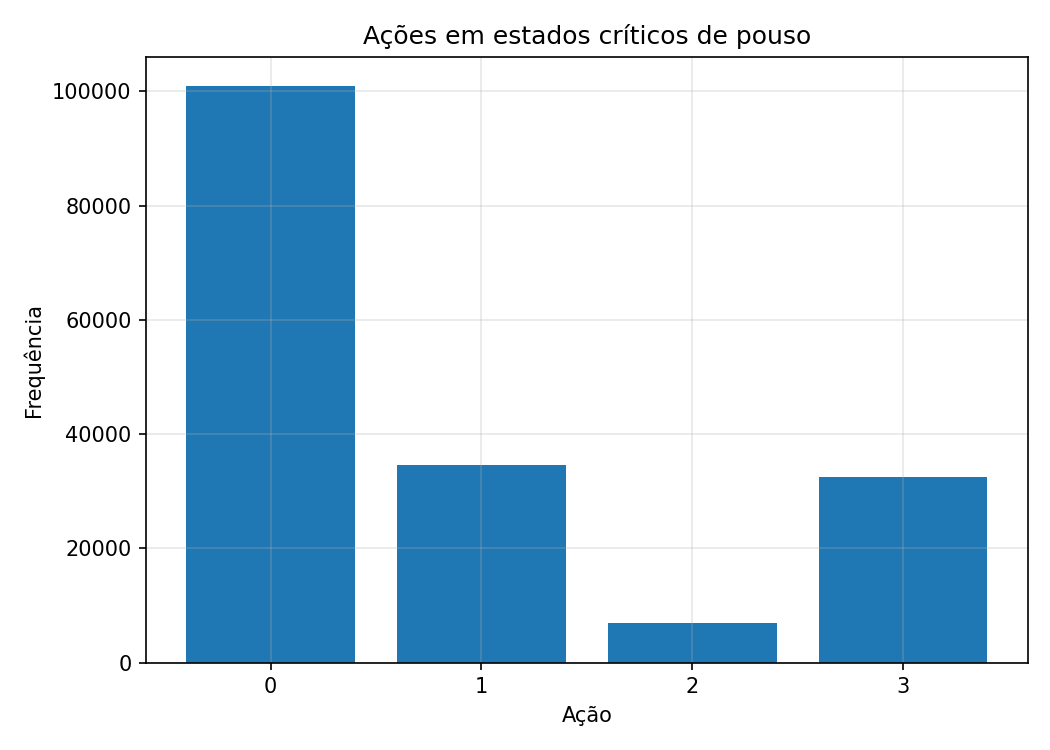

In [ ]:
plot_acoes_em_estado_critico(replay_buffer.buffer, save_img)

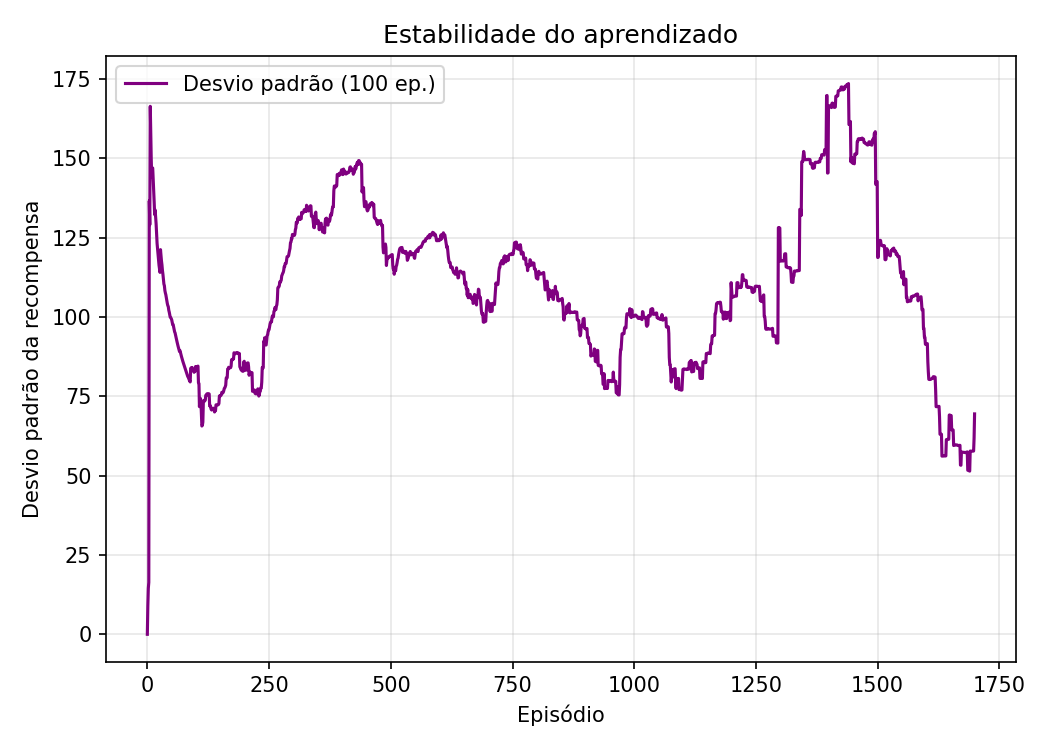

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

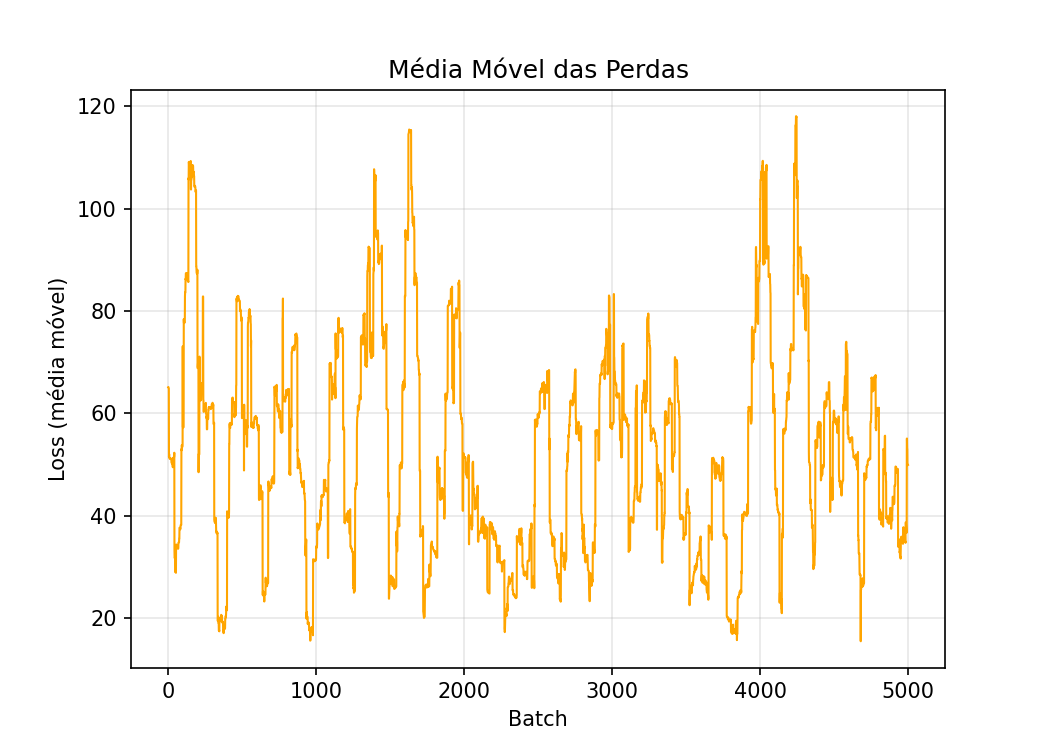

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_f3308dab32.pt
Vídeo gerado: videos/video-f3eba5689e-episode-0.mp4
Recompensa total: 249.62


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_f3308dab32.pt
Vídeo gerado: videos/video-b9c4fa9347-episode-0.mp4
Recompensa total: 192.63


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_f3308dab32.pt
Vídeo gerado: videos/video-938193dc15-episode-0.mp4
Recompensa total: 267.04


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_f3308dab32.pt
Vídeo gerado: videos/video-0b9b8a7b3b-episode-0.mp4
Recompensa total: -55.35


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_f3308dab32.pt
Vídeo gerado: videos/video-544153affa-episode-0.mp4
Recompensa total: 198.34


#5. Execução (2026)


In [ ]:
# Parâmetros de Execução Otimizados
seed = 2026
set_seed(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
env_name = "LunarLander-v3"
num_episodes = 1700
capacity = 800000
batch_size = 16
n_step = 3
tau = 0.001
gamma = 0.99
lr = 5e-4
hidden_layers = [11, 11, 11]
warmup_episodes = 100
cheb_degree = 7 # grau das bases de Chebyshev

# Cria o ambiente
env = gym.make(env_name)
env.reset(seed=seed)
env.action_space.seed(seed)

input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n

# Configuração da rede KKAN
modelo = RLModelKKAN(
    input_dim=input_dim,
    internal_hidden=hidden_layers,
    cheb_degree=cheb_degree,
    output_dim=output_dim
).to(device)

# Inicializa otimizador, agente e buffer
optimizer = torch.optim.Adam(modelo.parameters(), lr, weight_decay=1e-4)
agent = Agente(modelo, optimizer, env, gamma, save_res)
replay_buffer = BufferMultiStep(capacity, n_step, gamma)

# Executa o treinamento
timer = Timer()

nome_agente, rewards, avg_rewards, best_reward, best_episode = run_experiment(
    env,
    agent,
    replay_buffer,
    num_episodes,
    batch_size,
    warmup_episodes,
    save_res,
)
timer.stop()


(01:07:49) Iniciou execução...
Rodando na cuda:0
Ep    1/1700 [WARMUP] | R: -168.81 | Media10: -168.81 | Media100: -168.81 | eps: 0.995 | Buf:     93
Ep    2/1700 [WARMUP] | R: -115.23 | Media10: -142.02 | Media100: -142.02 | eps: 0.990 | Buf:    181
Ep    3/1700 [WARMUP] | R: -254.44 | Media10: -179.49 | Media100: -179.49 | eps: 0.985 | Buf:    252
Ep    4/1700 [WARMUP] | R:  -77.92 | Media10: -154.10 | Media100: -154.10 | eps: 0.980 | Buf:    343
Ep    5/1700 [WARMUP] | R: -107.74 | Media10: -144.82 | Media100: -144.82 | eps: 0.975 | Buf:    425
Ep    6/1700 [WARMUP] | R: -108.04 | Media10: -138.69 | Media100: -138.69 | eps: 0.970 | Buf:    486
Ep    7/1700 [WARMUP] | R: -128.04 | Media10: -137.17 | Media100: -137.17 | eps: 0.966 | Buf:    627
Ep    8/1700 [WARMUP] | R:  -83.98 | Media10: -130.52 | Media100: -130.52 | eps: 0.961 | Buf:    702
Ep    9/1700 [WARMUP] | R: -246.03 | Media10: -143.36 | Media100: -143.36 | eps: 0.956 | Buf:    798
Ep   10/1700 [WARMUP] | R:  -81.24 | Media

In [ ]:
caminho_arquivo = os.path.join(save_res, nome_agente)
print(f'Download {caminho_arquivo}')
# Verifica se o arquivo existe antes de tentar baixar
if os.path.exists(caminho_arquivo):
    files.download(caminho_arquivo)
else:
    print("Erro: O arquivo não foi encontrado na pasta /resultados.")

Download resultados/kkan_agente_88b20d81d6.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#6. Resultados (2026)

In [ ]:
print('seed', seed)
print('device', device)
print('env_name', env_name)
print('num_episodes', num_episodes)
print('capacity', capacity)
print('batch_size', batch_size)
print('n_step', n_step)
print('tau', tau)
print('gamma', gamma)
print('lr', lr)
print('hidden_layers', hidden_layers)
print('warmup_episodes', warmup_episodes)

## Desempenho

In [ ]:
plot_desempenho(rewards, best_reward, best_episode)

Desempenho:
 Melhor resultado: 295.68 (episódio 1661)
 Melhor média (100 ep): 242.61 (episódio 1575)
 Média últimos (100 ep): 230.57 ± 75.48
 Taxa de sucesso (>200): 90.0% (90/100)
Conclusão:
 SUCESSO! Agente RESOLVEU o ambiente!


In [ ]:
with torch.cuda.device(0):
  macs, params = get_model_complexity_info(
      modelo,
      (input_dim,),
      as_strings=True,
      print_per_layer_stat=True,
      verbose=True,
  )
print("FLOPs (MACs):", macs)
print("Parâmetros:", params)

RLModelKKAN(
  715, 99.444% Params, 715.0 Mac, 100.000% MACs, 
  (inner): KKANInternalBlock(
    363, 50.487% Params, 363.0 Mac, 50.769% MACs, 
    (rede): Sequential(
      363, 50.487% Params, 363.0 Mac, 50.769% MACs, 
      (0): Linear(99, 13.769% Params, 99.0 Mac, 13.846% MACs, in_features=8, out_features=11, bias=True)
      (1): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
      (2): Linear(132, 18.359% Params, 132.0 Mac, 18.462% MACs, in_features=11, out_features=11, bias=True)
      (3): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
      (4): Linear(132, 18.359% Params, 132.0 Mac, 18.462% MACs, in_features=11, out_features=11, bias=True)
      (5): Tanh(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    )
  )
  (outer): KKANExternalBlock(
    352, 48.957% Params, 352.0 Mac, 49.231% MACs, 
    (cheb): ChebyshevLayer(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    (linear): Linear(352, 48.957% Params, 352.0 Mac, 49.231% MACs, in_features=88, out_features=4, bias=False)
  )
)
FLOPs (

## Arquitetura da Rede

In [ ]:
print(modelo)

RLModelKKAN(
  (inner): KKANInternalBlock(
    (rede): Sequential(
      (0): Linear(in_features=8, out_features=11, bias=True)
      (1): Tanh()
      (2): Linear(in_features=11, out_features=11, bias=True)
      (3): Tanh()
      (4): Linear(in_features=11, out_features=11, bias=True)
      (5): Tanh()
    )
  )
  (outer): KKANExternalBlock(
    (cheb): ChebyshevLayer()
    (linear): Linear(in_features=88, out_features=4, bias=False)
  )
)


In [ ]:
summary(modelo, input_size=(1, input_dim))

Layer (type:depth-idx)                   Output Shape              Param #
RLModelKKAN                              [1, 4]                    --
├─KKANInternalBlock: 1-1                 [1, 11]                   --
│    └─Sequential: 2-1                   [1, 11]                   --
│    │    └─Linear: 3-1                  [1, 11]                   99
│    │    └─Tanh: 3-2                    [1, 11]                   --
│    │    └─Linear: 3-3                  [1, 11]                   132
│    │    └─Tanh: 3-4                    [1, 11]                   --
│    │    └─Linear: 3-5                  [1, 11]                   132
│    │    └─Tanh: 3-6                    [1, 11]                   --
├─KKANExternalBlock: 1-2                 [1, 4]                    4
│    └─ChebyshevLayer: 2-2               [1, 88]                   --
│    └─Linear: 2-3                       [1, 4]                    352
Total params: 719
Trainable params: 719
Non-trainable params: 0
Total mult-adds (Un

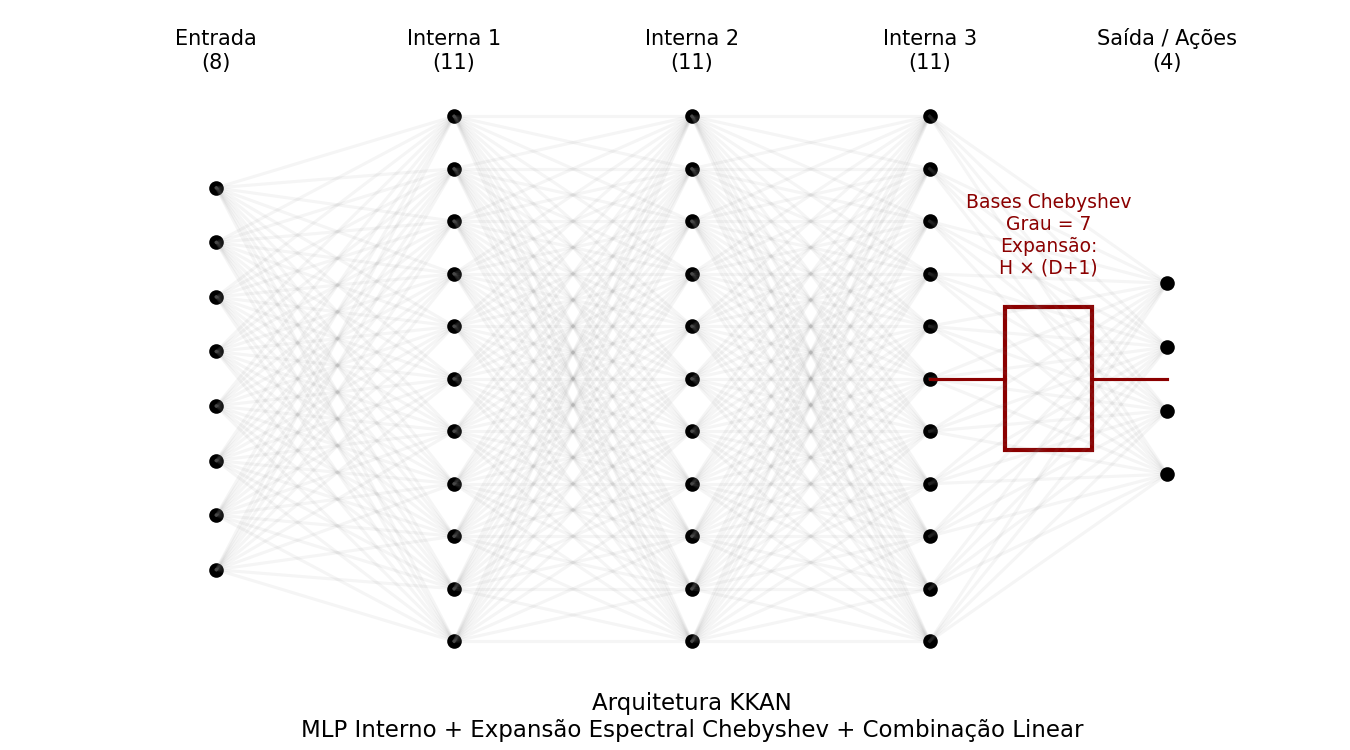

In [ ]:
plot_kkan_arquitetura(input_dim, hidden_layers, cheb_degree, output_dim, save_img)

## Gráficos

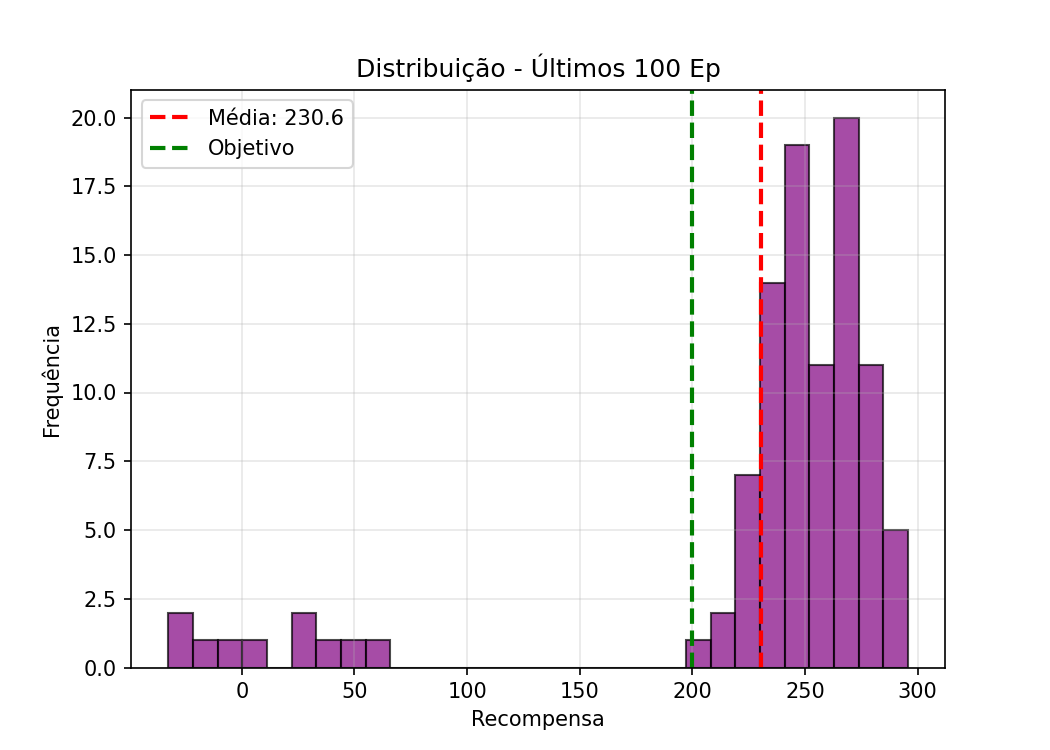

In [ ]:
plot_distribuicao_recompensa(rewards, save_img)

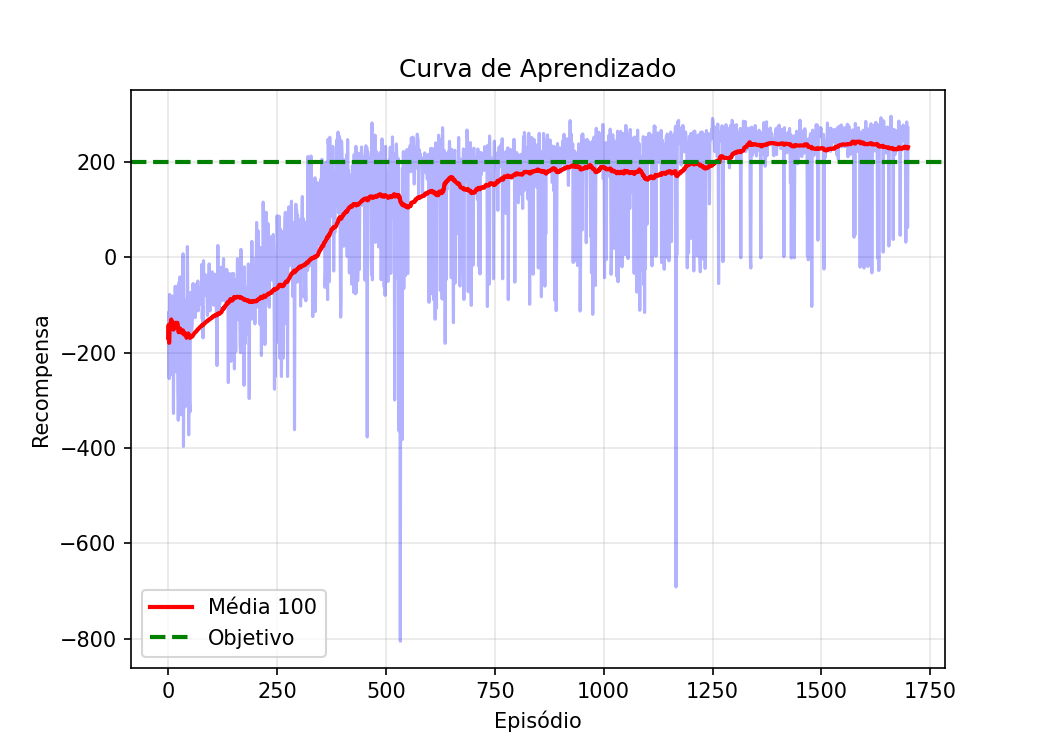

In [ ]:
plot_curva_aprendizado(rewards, save_img)

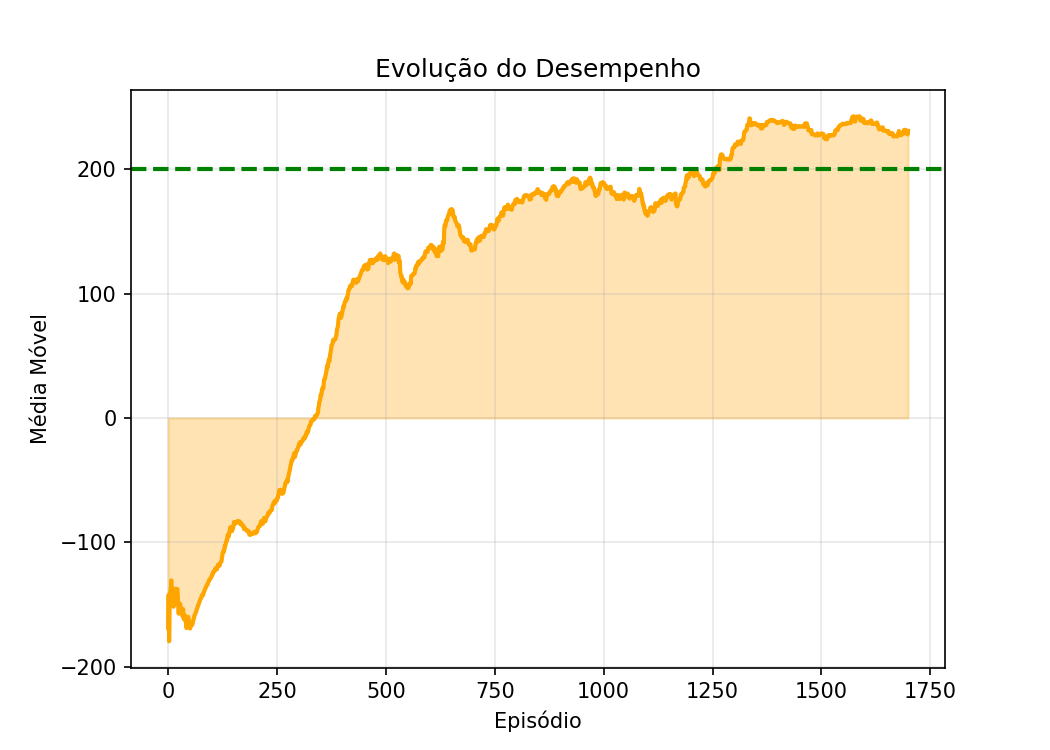

In [ ]:
plot_evolucao_desempenho(rewards, save_img)

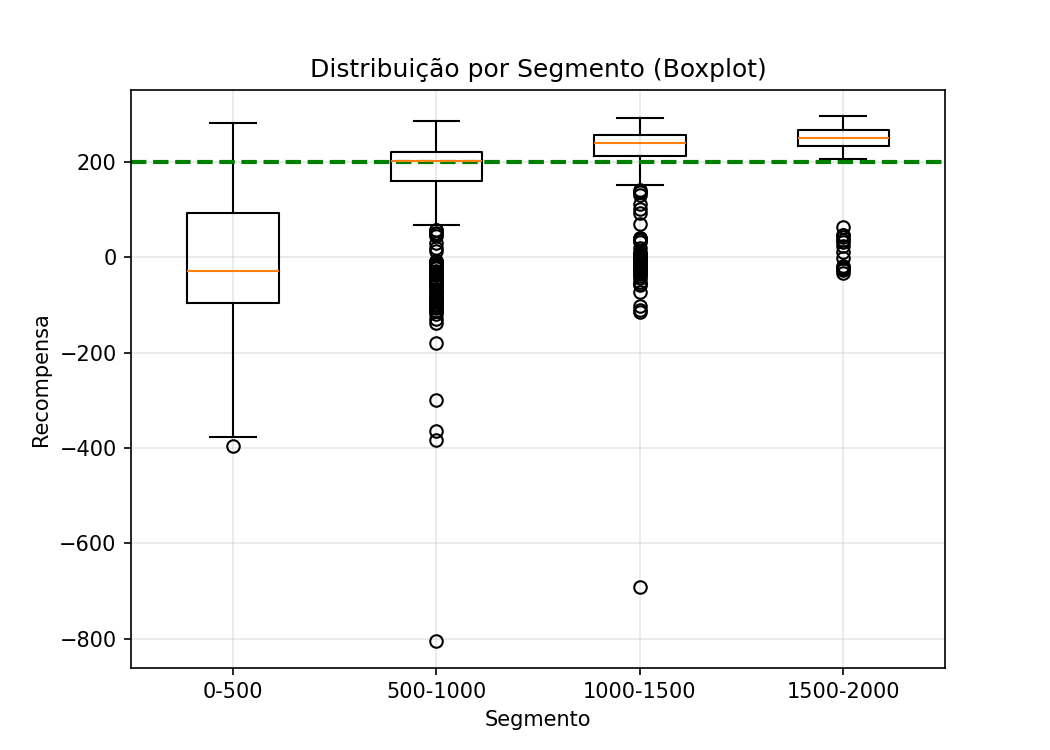

In [ ]:
plot_distribuicao_segmento(rewards, save_img)

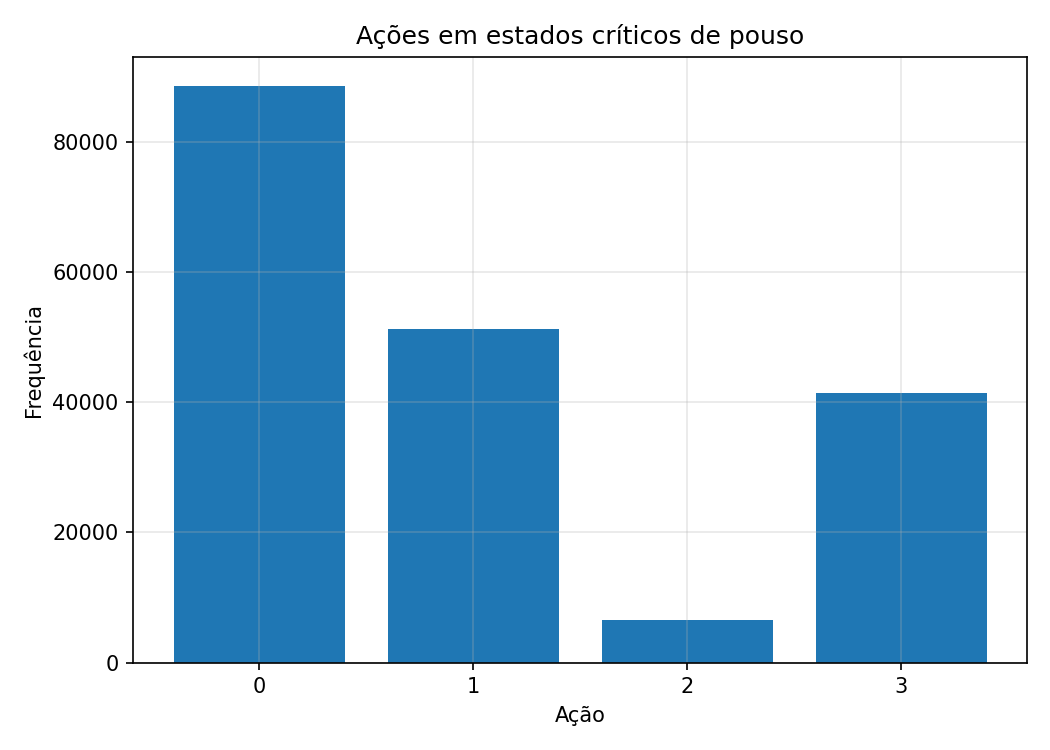

In [ ]:
plot_acoes_em_estado_critico(replay_buffer.buffer, save_img)

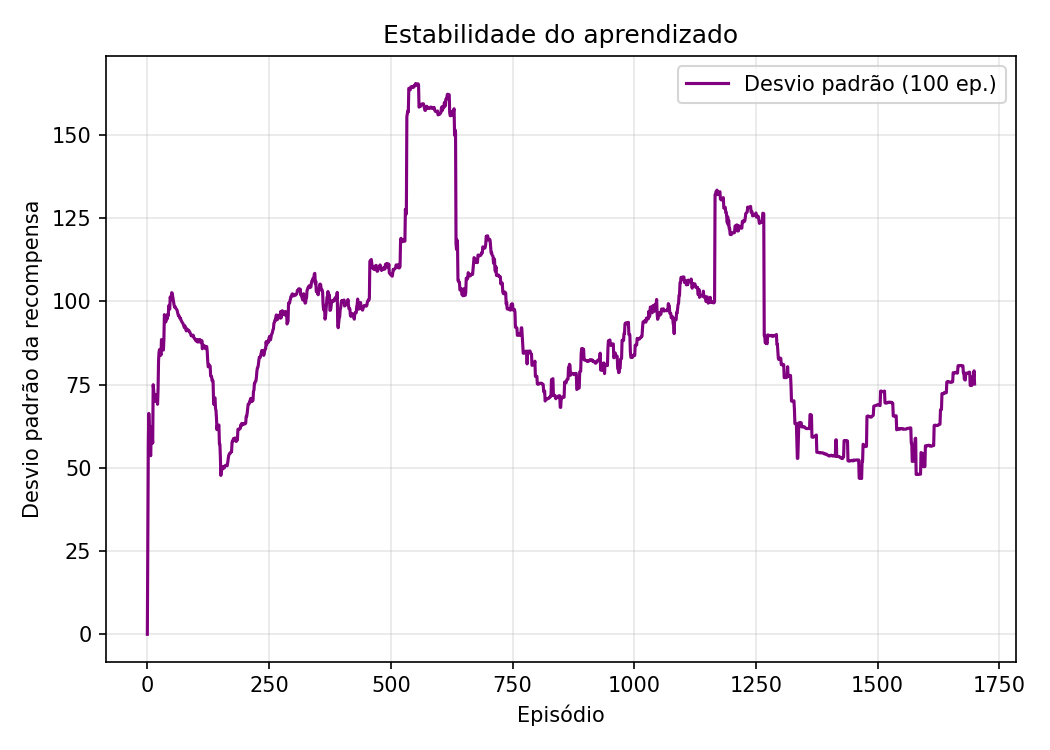

In [ ]:
plot_desvio_padrao_recompensa(rewards, save_img)

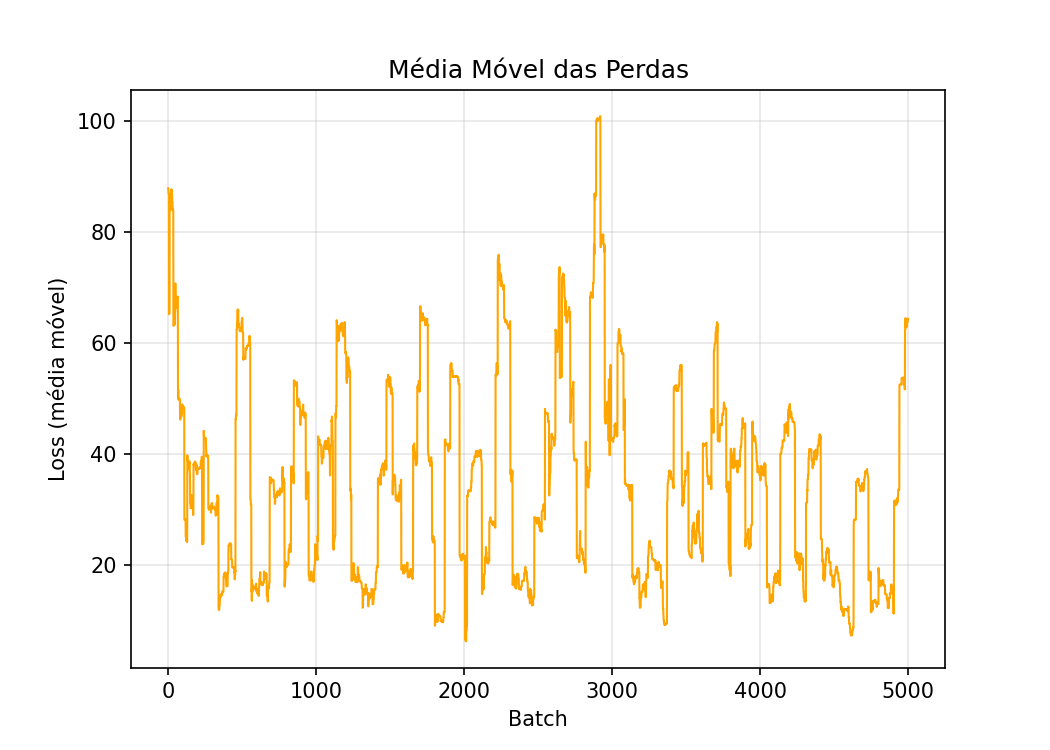

In [ ]:
plot_losses(agent.losses, save_img)

##Vídeos

In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_88b20d81d6.pt
Vídeo gerado: videos/video-21fa1d15b7-episode-0.mp4
Recompensa total: 279.38


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_88b20d81d6.pt
Vídeo gerado: videos/video-73d972ecad-episode-0.mp4
Recompensa total: 223.40


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_88b20d81d6.pt
Vídeo gerado: videos/video-b880e3449f-episode-0.mp4
Recompensa total: 233.68


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_88b20d81d6.pt
Vídeo gerado: videos/video-95831257da-episode-0.mp4
Recompensa total: 223.70


In [ ]:
plot_video(env, input_dim, hidden_layers, output_dim, gamma, save_res, nome_agente)

Gravando vídeo do melhor agente...
Agente carregado de: resultados/kkan_agente_88b20d81d6.pt
Vídeo gerado: videos/video-b7b9b1f243-episode-0.mp4
Recompensa total: 246.73


#---